In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
qweemreee_nyc_yellow_taxi_record_23_24_25_path = kagglehub.dataset_download('qweemreee/nyc-yellow-taxi-record-23-24-25')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/qweemreee/nyc-yellow-taxi-record-23-24-25/2024/yellow_tripdata_2024-09.parquet
/kaggle/input/datasets/qweemreee/nyc-yellow-taxi-record-23-24-25/2024/yellow_tripdata_2024-03.parquet
/kaggle/input/datasets/qweemreee/nyc-yellow-taxi-record-23-24-25/2024/yellow_tripdata_2024-04.parquet
/kaggle/input/datasets/qweemreee/nyc-yellow-taxi-record-23-24-25/2024/yellow_tripdata_2024-02.parquet
/kaggle/input/datasets/qweemreee/nyc-yellow-taxi-record-23-24-25/2024/yellow_tripdata_2024-05.parquet
/kaggle/input/datasets/qweemreee/nyc-yellow-taxi-record-23-24-25/2024/yellow_tripdata_2024-07.parquet
/kaggle/input/datasets/qweemreee/nyc-yellow-taxi-record-23-24-25/2024/yellow_tripdata_2024-10.parquet
/kaggle/input/datasets/qweemreee/nyc-yellow-taxi-record-23-24-25/2024/yellow_tripdata_2024-06.parquet
/kaggle/input/datasets/qweemreee/nyc-yellow-taxi-record-23-24-25/2024/yellow_tripdata_2024-11.parquet
/kaggle/input/datasets/qweemreee/nyc-yellow-taxi-record-23-24-25/2024/yellow_tripd

### Pipeline
1. Memory-Efficient Data Ingestion (Aggregate-First Chunking)
2. Spatio-Temporal & Yearly Seasonality Feature Engineering
3. Chronological Train / Validation / Test Split
4. GPU LightGBM + Optuna Hyperparameter Tuning
5. XAI (SHAP) & Evaluation

## 0 · Environment Setup & Imports

In [ ]:
# ---------------------------------------------------------------------------
# Paket kurulumu (Kaggle'da bir kez çalıştır, re-run güvenli)
# ---------------------------------------------------------------------------
import subprocess, sys

PKGS = ["lightgbm", "optuna", "shap", "holidays", "pyarrow"]
for pkg in PKGS:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", "--upgrade", pkg]
    )
print("Tüm paketler hazır.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 54.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.2/51.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.8 MB/s eta 0:00:00
Tüm paketler hazır.


In [ ]:
# ---------------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------------
import os
import gc
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler

import shap
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import holidays as hol_pkg
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ---------------------------------------------------------------------------
# Global ayarlar
# ---------------------------------------------------------------------------
os.environ["LIGHTGBM_GPU_USE_DP"]  = "0"   # single-precision → nvcc uyarıları azalır
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"   # GPU hata izleme kolaylaşır

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

SEED = 42
np.random.seed(SEED)

print(f"LightGBM : {lgb.__version__}")
print(f"Optuna   : {optuna.__version__}")
print(f"SHAP     : {shap.__version__}")

LightGBM : 4.6.0
Optuna   : 4.8.0
SHAP     : 0.51.0


## 1 · Memory-Efficient Data Ingestion (Aggregate-First Chunking)

In [ ]:
# ---------------------------------------------------------------------------
# 1-A  Dosya keşfi
# ---------------------------------------------------------------------------

# Klasör ismini dert etmemek için doğrudan Kaggle'ın ana input dizininden root taraması (recursive globbing) yapıyoruz
DATA_ROOT = Path("/kaggle/input")

# 2023, 2024 ve 2025 yıllarına ait dosyaları bulmak için doğru glob deseni: 202[3-5]
parquet_files = sorted(
    DATA_ROOT.rglob("yellow_tripdata_202[3-5]*.parquet")
)

# Manuel hata yakalama (Exception Handling) mekanizması
if len(parquet_files) != 36:
    print(f"HATA: 36 dosya bekleniyordu ama {len(parquet_files)} adet dosya bulundu.")
    print("Mevcut bulunan dosyalar şunlar:")
    for f in parquet_files:
        print(f.name)
    raise AssertionError("Lütfen 3 yıllık (36 aylık) tüm Yellow Taxi verilerini Kaggle'a eklediğinizden emin olun.")

log.info("%d parquet dosyası bulundu.", len(parquet_files))
for fp in parquet_files:
    print(" ", fp.name)

15:20:40  36 parquet dosyası bulundu.


  yellow_tripdata_2023-01.parquet
  yellow_tripdata_2023-02.parquet
  yellow_tripdata_2023-03.parquet
  yellow_tripdata_2023-04.parquet
  yellow_tripdata_2023-05.parquet
  yellow_tripdata_2023-06.parquet
  yellow_tripdata_2023-07.parquet
  yellow_tripdata_2023-08.parquet
  yellow_tripdata_2023-09.parquet
  yellow_tripdata_2023-10.parquet
  yellow_tripdata_2023-11.parquet
  yellow_tripdata_2023-12.parquet
  yellow_tripdata_2024-01.parquet
  yellow_tripdata_2024-02.parquet
  yellow_tripdata_2024-03.parquet
  yellow_tripdata_2024-04.parquet
  yellow_tripdata_2024-05.parquet
  yellow_tripdata_2024-06.parquet
  yellow_tripdata_2024-07.parquet
  yellow_tripdata_2024-08.parquet
  yellow_tripdata_2024-09.parquet
  yellow_tripdata_2024-10.parquet
  yellow_tripdata_2024-11.parquet
  yellow_tripdata_2024-12.parquet
  yellow_tripdata_2025-01.parquet
  yellow_tripdata_2025-02.parquet
  yellow_tripdata_2025-03.parquet
  yellow_tripdata_2025-04.parquet
  yellow_tripdata_2025-05.parquet
  yellow_tripd

In [ ]:
# ---------------------------------------------------------------------------
# 1-B  Aggregate-First Chunking  (~110 M ham satır OOM'suz işlenir)
# ---------------------------------------------------------------------------
REQUIRED_COLS = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "trip_distance",
    "fare_amount",
]
MAX_SPEED_MPH = 100.0


def _aggregate_file(fp: Path) -> pd.DataFrame:
    """Tek parquet dosyasını oku, filtrele, saatlik aggregate döndür."""
    table = pq.read_table(fp, columns=REQUIRED_COLS)
    df = table.to_pandas()

    df["tpep_pickup_datetime"] = pd.to_datetime(
        df["tpep_pickup_datetime"], errors="coerce", utc=False
    )
    df["tpep_dropoff_datetime"] = pd.to_datetime(
        df["tpep_dropoff_datetime"], errors="coerce", utc=False
    )

    # Kinematik filtreler
    df["duration_sec"] = (
        df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
    ).dt.total_seconds()
    df["speed_mph"] = df["trip_distance"] / (df["duration_sec"] / 3600.0)

    mask = (
        (df["duration_sec"] > 0)
        & (df["fare_amount"] > 0)
        & (df["speed_mph"] <= MAX_SPEED_MPH)
        & df["PULocationID"].notna()
        & df["tpep_pickup_datetime"].notna()
    )
    df = df.loc[mask].copy()

    df["time_bin"]     = df["tpep_pickup_datetime"].dt.floor("h")
    df["PULocationID"] = df["PULocationID"].astype("int16")

    agg = (
        df.groupby(["PULocationID", "time_bin"], sort=False)
        .size()
        .reset_index(name="pickup_count")
    )
    return agg


chunk_list: list[pd.DataFrame] = []

for i, fp in enumerate(parquet_files, 1):
    log.info("[%d/36] İşleniyor: %s", i, fp.name)
    chunk = _aggregate_file(fp)
    chunk_list.append(chunk)
    del chunk
    gc.collect()

log.info("%d chunk birleştiriliyor …", len(chunk_list))
master_df = pd.concat(chunk_list, ignore_index=True)
del chunk_list
gc.collect()

log.info("Master df şekli (zero-padding öncesi): %s", master_df.shape)
master_df.head()

15:20:40  [1/36] İşleniyor: yellow_tripdata_2023-01.parquet
15:20:41  [2/36] İşleniyor: yellow_tripdata_2023-02.parquet
15:20:43  [3/36] İşleniyor: yellow_tripdata_2023-03.parquet
15:20:44  [4/36] İşleniyor: yellow_tripdata_2023-04.parquet
15:20:45  [5/36] İşleniyor: yellow_tripdata_2023-05.parquet
15:20:47  [6/36] İşleniyor: yellow_tripdata_2023-06.parquet
15:20:48  [7/36] İşleniyor: yellow_tripdata_2023-07.parquet
15:20:49  [8/36] İşleniyor: yellow_tripdata_2023-08.parquet
15:20:50  [9/36] İşleniyor: yellow_tripdata_2023-09.parquet
15:20:51  [10/36] İşleniyor: yellow_tripdata_2023-10.parquet
15:20:52  [11/36] İşleniyor: yellow_tripdata_2023-11.parquet
15:20:53  [12/36] İşleniyor: yellow_tripdata_2023-12.parquet
15:20:54  [13/36] İşleniyor: yellow_tripdata_2024-01.parquet
15:20:55  [14/36] İşleniyor: yellow_tripdata_2024-02.parquet
15:20:56  [15/36] İşleniyor: yellow_tripdata_2024-03.parquet
15:20:57  [16/36] İşleniyor: yellow_tripdata_2024-04.parquet
15:20:58  [17/36] İşleniyor: yell

,PULocationID,time_bin,pickup_count
0,161,2023-01-01,193
1,43,2023-01-01,93
2,48,2023-01-01,125
3,138,2023-01-01,16
4,107,2023-01-01,176


# ---------------------------------------------------------------------------
# 1-C  Global zero-padding — 2023-01-01 … 2025-12-31 sürekli saatlik grid
# ---------------------------------------------------------------------------
# Önce concat sonrası duplicate (loc+hour) satırları topla

In [ ]:

master_df = (
    master_df
    .groupby(["PULocationID", "time_bin"], sort=True)["pickup_count"]
    .sum()
    .reset_index()
)

full_range = pd.date_range(
    start="2023-01-01 00:00:00",
    end="2025-12-31 23:00:00",
    freq="h",
    name="time_bin",
)

all_locations = master_df["PULocationID"].unique()
log.info("Benzersiz PULocationID sayısı : %d", len(all_locations))
log.info(
    "Grid boyutu : %d saat × %d lokasyon = %d satır",
    len(full_range), len(all_locations),
    len(full_range) * len(all_locations),
)

full_idx = pd.MultiIndex.from_product(
    [all_locations, full_range],
    names=["PULocationID", "time_bin"],
)

master_df = (
    master_df
    .set_index(["PULocationID", "time_bin"])
    .reindex(full_idx, fill_value=0)
    .reset_index()
)

master_df.sort_values(["PULocationID", "time_bin"], inplace=True)
master_df.reset_index(drop=True, inplace=True)

log.info("Master df şekli (zero-padding sonrası): %s", master_df.shape)
master_df.dtypes

15:21:24  Benzersiz PULocationID sayısı : 263
15:21:24  Grid boyutu : 26304 saat × 263 lokasyon = 6917952 satır
15:21:26  Master df şekli (zero-padding sonrası): (6917952, 3)


PULocationID             int16
time_bin        datetime64[ns]
pickup_count             int64
dtype: object

## 2 · Spatio-Temporal & Yearly Seasonality Feature Engineering

In [ ]:
# ---------------------------------------------------------------------------
# 2-A  Tatil günleri lookup (US / NY eyaleti)
# ---------------------------------------------------------------------------
ny_holidays = hol_pkg.country_holidays(
    "US", subdiv="NY", years=range(2023, 2026)
)
holiday_dates: set = set(ny_holidays.keys())
log.info("NY tatil günü sayısı: %d", len(holiday_dates))

15:21:26  NY tatil günü sayısı: 45


In [ ]:
# ---------------------------------------------------------------------------
# 2-B  Feature engineering fonksiyonu (her lokasyon grubuna ayrı uygulanır)
# ---------------------------------------------------------------------------
def _engineer_features(grp: pd.DataFrame) -> pd.DataFrame:
    """Temporal, cyclical, lag, rolling ve holiday feature'ları ekle."""
    grp = grp.copy()
    tb  = grp["time_bin"]

    # -- Cyclical zaman kodlaması (makro mevsimsellik)
    hour  = tb.dt.hour          # 0-23
    dow   = tb.dt.dayofweek     # 0 = Pazartesi
    month = tb.dt.month         # 1-12
    doy   = tb.dt.dayofyear     # 1-365/366

    grp["sin_hour"]  = np.sin(2 * np.pi * hour  / 24)
    grp["cos_hour"]  = np.cos(2 * np.pi * hour  / 24)
    grp["sin_dow"]   = np.sin(2 * np.pi * dow   / 7)
    grp["cos_dow"]   = np.cos(2 * np.pi * dow   / 7)
    grp["sin_month"] = np.sin(2 * np.pi * month / 12)
    grp["cos_month"] = np.cos(2 * np.pi * month / 12)
    grp["sin_doy"]   = np.sin(2 * np.pi * doy   / 365)
    grp["cos_doy"]   = np.cos(2 * np.pi * doy   / 365)

    # -- Kısa vadeli lag'lar (yıllık lag yok → dev satır kaybı önlenir)
    pc = grp["pickup_count"]
    grp["lag_1"]   = pc.shift(1)
    grp["lag_2"]   = pc.shift(2)
    grp["lag_24"]  = pc.shift(24)    # dünün aynı saati
    grp["lag_168"] = pc.shift(168)   # geçen haftanın aynı saati

    # -- Rolling istatistikler (lag-1'den → sızıntı yok)
    grp["roll_mean_3h"] = pc.shift(1).rolling(3,  min_periods=1).mean()
    grp["roll_mean_6h"] = pc.shift(1).rolling(6,  min_periods=1).mean()

    # -- Tatil bayrağı
    grp["is_holiday"] = (
        tb.dt.date
        .apply(lambda d: 1 if d in holiday_dates else 0)
        .astype("int8")
    )

    return grp


log.info(
    "%d lokasyon grubu için feature engineering uygulanıyor …",
    master_df["PULocationID"].nunique(),
)

feat_df = (
    master_df
    .groupby("PULocationID", group_keys=False)
    .apply(_engineer_features)
)

gc.collect()
log.info("Feature engineering sonrası şekil: %s", feat_df.shape)

15:21:26  263 lokasyon grubu için feature engineering uygulanıyor …
15:21:35  Feature engineering sonrası şekil: (6917952, 18)


In [ ]:
# ---------------------------------------------------------------------------
# 2-C  NaN satırlarını düşür (168 saatlik lag ısınma periyodu)
# ---------------------------------------------------------------------------
n_before = len(feat_df)
feat_df.dropna(inplace=True)
feat_df.reset_index(drop=True, inplace=True)
log.info(
    "%d NaN satır düşürüldü (168-h ısınma). Kalan: %d",
    n_before - len(feat_df), len(feat_df),
)


# ---------------------------------------------------------------------------
# 2-D  Dtype downcast → bellek tasarrufu (~%50)
# ---------------------------------------------------------------------------
def _downcast(df: pd.DataFrame) -> pd.DataFrame:
    """float64 → float32, int64 → int32 dönüşümü."""
    for col in df.select_dtypes(include="float64").columns:
        df[col] = df[col].astype("float32")
    for col in df.select_dtypes(include="int64").columns:
        df[col] = df[col].astype("int32")
    return df


feat_df = _downcast(feat_df)
log.info(
    "Downcast sonrası bellek: %.1f MB",
    feat_df.memory_usage(deep=True).sum() / 1e6,
)
feat_df.dtypes

15:21:36  44184 NaN satır düşürüldü (168-h ısınma). Kalan: 6873768
15:21:37  Downcast sonrası bellek: 488.0 MB


PULocationID             int16
time_bin        datetime64[ns]
pickup_count             int32
sin_hour               float32
cos_hour               float32
sin_dow                float32
cos_dow                float32
sin_month              float32
cos_month              float32
sin_doy                float32
cos_doy                float32
lag_1                  float32
lag_2                  float32
lag_24                 float32
lag_168                float32
roll_mean_3h           float32
roll_mean_6h           float32
is_holiday                int8
dtype: object

## 3 · Chronological Train / Validation / Test Split

In [ ]:
# ---------------------------------------------------------------------------
# 3-A  Bölünme sınırları
# ---------------------------------------------------------------------------
# Train : 2023-01-01 → 2024-12-31  (24 ay)
# Val   : 2025-01-01 → 2025-09-30  (9 ay  — Optuna için)
# Test  : 2025-10-01 → 2025-12-31  (3 ay  — Thanksgiving, Noel, Yılbaşı)

TRAIN_END = pd.Timestamp("2024-12-31 23:00:00")
VAL_END   = pd.Timestamp("2025-09-30 23:00:00")

train_df = feat_df[feat_df["time_bin"] <= TRAIN_END].copy()
val_df   = feat_df[
    (feat_df["time_bin"] > TRAIN_END) & (feat_df["time_bin"] <= VAL_END)
].copy()
test_df  = feat_df[feat_df["time_bin"] > VAL_END].copy()

log.info("Train : %s → %s  (%d satır)",
         train_df["time_bin"].min(), train_df["time_bin"].max(), len(train_df))
log.info("Val   : %s → %s  (%d satır)",
         val_df["time_bin"].min(),   val_df["time_bin"].max(),   len(val_df))
log.info("Test  : %s → %s  (%d satır)",
         test_df["time_bin"].min(),  test_df["time_bin"].max(),  len(test_df))


# ---------------------------------------------------------------------------
# 3-B  Feature & target tanımları
# ---------------------------------------------------------------------------
NON_FEATURE_COLS = {"time_bin", "pickup_count", "PULocationID"}
FEATURE_COLS     = [c for c in feat_df.columns if c not in NON_FEATURE_COLS]
TARGET_COL       = "pickup_count"

log.info("Feature sayısı: %d → %s", len(FEATURE_COLS), FEATURE_COLS)

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_val,   y_val   = val_df[FEATURE_COLS],   val_df[TARGET_COL]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df[TARGET_COL]

15:21:38  Train : 2023-01-08 00:00:00 → 2024-12-31 23:00:00  (4569888 satır)
15:21:38  Val   : 2025-01-01 00:00:00 → 2025-09-30 23:00:00  (1723176 satır)
15:21:38  Test  : 2025-10-01 00:00:00 → 2025-12-31 23:00:00  (580704 satır)
15:21:38  Feature sayısı: 15 → ['sin_hour', 'cos_hour', 'sin_dow', 'cos_dow', 'sin_month', 'cos_month', 'sin_doy', 'cos_doy', 'lag_1', 'lag_2', 'lag_24', 'lag_168', 'roll_mean_3h', 'roll_mean_6h', 'is_holiday']


## 4 · GPU LightGBM + Optuna


In [ ]:
# ---------------------------------------------------------------------------
# 4-A  LightGBM Dataset yapımı
#
# CRITICAL: max_bin ve feature_pre_filter sadece ve sadece "params" dict
#           içinde gönderilmelidir. Aksi takdirde TypeError veya [Fatal] hatası döner.
# ---------------------------------------------------------------------------
DATASET_MAX_BIN = 127   # 63=hız, 127=denge (T4/P100 için ideal), 255=hassasiyet

lgb_train = lgb.Dataset(
    X_train,
    label          = y_train,
    free_raw_data  = False,
    # TÜM AYARLAR PARAMS İÇİNDE BİRLEŞTİRİLDİ
    params         = {
        "max_bin": DATASET_MAX_BIN,
        "feature_pre_filter": False  # CRITICAL: GPU+Poisson hatasını önler
    },
)

lgb_val = lgb.Dataset(
    X_val,
    label          = y_val,
    reference      = lgb_train,
    free_raw_data  = False,
    # TÜM AYARLAR PARAMS İÇİNDE BİRLEŞTİRİLDİ
    params         = {
        "max_bin": DATASET_MAX_BIN,
        "feature_pre_filter": False  # train ile eşleşmeli
    },
)

log.info("LightGBM Dataset'leri hazır (max_bin=%d, feature_pre_filter=False).", DATASET_MAX_BIN)

15:21:38  LightGBM Dataset'leri hazır (max_bin=127, feature_pre_filter=False).


In [ ]:
# ---------------------------------------------------------------------------
# 4-B  Optuna objective
#
# GPU seçimi:
#   GPU_DEVICE_ID = 0  →  T4 #1 veya P100 (her zaman device 0)
#   GPU_DEVICE_ID = 1  →  T4 #2 (sadece T4 x2 seçiliyse)
# ---------------------------------------------------------------------------
GPU_DEVICE_ID    = 0      # T4 x2 → 0,  P100 → 0
N_OPTUNA_TRIALS  = 30
MAX_BOOST_ROUNDS = 1500
EARLY_STOP       = 75


def _optuna_objective(trial: optuna.Trial) -> float:
    """Bir Optuna trial için validation RMSE döndür."""

    params = {
        # ── Sabit parametreler ───────────────────────────────────────────────
        "objective"          : "poisson",
        "metric"             : "rmse",
        "device_type"        : "gpu",
        "gpu_platform_id"    : 0,
        "gpu_device_id"      : GPU_DEVICE_ID,
        "num_gpu"            : 1,
        "verbosity"          : -1,
        "seed"               : SEED,
        "feature_pre_filter" : False,   # CRITICAL
        "force_row_wise"     : True,    # T4 & P100'de stabil
        # max_bin buraya YAZILMAZ — Dataset'te zaten tanımlı

        # ── Optuna tarafından ayarlanan parametreler ─────────────────────────
        "learning_rate"     : trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves"        : trial.suggest_int("num_leaves", 63, 511),
        "max_depth"         : trial.suggest_int("max_depth", 5, 12),
        "min_child_samples" : trial.suggest_int("min_child_samples", 20, 300),
        "feature_fraction"  : trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction"  : trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq"      : trial.suggest_int("bagging_freq", 1, 10),
        "lambda_l1"         : trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2"         : trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
        "min_split_gain"    : trial.suggest_float("min_split_gain", 0.0, 1.0),
    }

    callbacks = [
        lgb.early_stopping(EARLY_STOP, verbose=False),
        lgb.log_evaluation(period=-1),   # tamamen sessiz
    ]

    booster = lgb.train(
        params,
        lgb_train,
        num_boost_round = MAX_BOOST_ROUNDS,
        valid_sets      = [lgb_val],
        callbacks       = callbacks,
    )

    trial.set_user_attr("best_iteration", booster.best_iteration)

    preds = booster.predict(X_val, num_iteration=booster.best_iteration)
    rmse  = float(np.sqrt(mean_squared_error(y_val, preds)))

    del booster
    gc.collect()

    return rmse


log.info(
    "Optuna study başlıyor (%d trial) — GPU device %d …",
    N_OPTUNA_TRIALS, GPU_DEVICE_ID,
)

study = optuna.create_study(
    direction  = "minimize",
    sampler    = TPESampler(seed=SEED, n_startup_trials=10),
    study_name = "lgb_poisson_nyc_taxi_gpu",
)

study.optimize(
    _optuna_objective,
    n_trials          = N_OPTUNA_TRIALS,
    show_progress_bar = True,
    gc_after_trial    = True,
)

log.info("En iyi val RMSE : %.4f", study.best_value)
log.info("En iyi params  : %s",   study.best_params)

# Trial özet tablosu
trial_df = pd.DataFrame([
    {
        "trial"  : t.number,
        "rmse"   : round(t.value, 4) if t.value is not None else None,
        "rounds" : t.user_attrs.get("best_iteration", "—"),
        "state"  : t.state.name,
    }
    for t in study.trials
]).sort_values("rmse")

print("\nOptuna Trial Özeti (RMSE sıralamasıyla):")
print(trial_df.to_string(index=False))

15:21:38  Optuna study başlıyor (30 trial) — GPU device 0 …


  0%|          | 0/30 [00:00<?, ?it/s]

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
20:31:02  En iyi val RMSE : 9.6218
20:31:02  En iyi params  : {'learning_rate': 0.022017071509657527, 'num_leaves': 402, 'max_depth': 12, 'min_child_samples': 44, 'feature_fraction': 0.5007665081355411, 'bagging_fraction': 0.5445558027111483, 'bagging_freq': 7, 'lambda_l1': 2.0702778363705633e-06, 'lambda_


Optuna Trial Özeti (RMSE sıralamasıyla):
 trial    rmse  rounds    state
    28  9.6218    1498 COMPLETE
    23  9.6232    1500 COMPLETE
    26  9.6232    1498 COMPLETE
    20  9.6294    1358 COMPLETE
    19  9.6371    1500 COMPLETE
    21  9.6391    1436 COMPLETE
    15  9.6517    1452 COMPLETE
    25  9.6546    1500 COMPLETE
    24  9.6793    1500 COMPLETE
     6  9.6822    1500 COMPLETE
    16  9.6892    1500 COMPLETE
     0  9.6894    1500 COMPLETE
    29  9.6913    1500 COMPLETE
    17  9.7022    1096 COMPLETE
    22  9.7111     778 COMPLETE
    27  9.7170    1306 COMPLETE
    12  9.7300    1500 COMPLETE
     9  9.7317    1500 COMPLETE
     1  9.7355    1500 COMPLETE
     8  9.7386    1073 COMPLETE
     2  9.7399    1499 COMPLETE
    10  9.7410    1500 COMPLETE
    11  9.7433    1500 COMPLETE
    14  9.7457    1500 COMPLETE
    13  9.7632    1500 COMPLETE
    18  9.8103    1500 COMPLETE
     7  9.8193    1499 COMPLETE
     5  9.8954    1020 COMPLETE
     3  9.9353    1496 COMPLET

In [ ]:
# ---------------------------------------------------------------------------
# 4-C  best_n_rounds güvenli şekilde al
#       TypeError önlemi: t.last_step is not None filtresi
# ---------------------------------------------------------------------------
valid_trials = [
    t for t in study.trials
    if t.last_step is not None
    and t.state == optuna.trial.TrialState.COMPLETE
    and "best_iteration" in t.user_attrs
]

if valid_trials:
    best_trial    = min(valid_trials, key=lambda t: t.value)
    best_n_rounds = best_trial.user_attrs["best_iteration"]
else:
    best_n_rounds = MAX_BOOST_ROUNDS

log.info("En iyi n_rounds: %d", best_n_rounds)

20:31:02  En iyi n_rounds: 1500


In [ ]:
# ---------------------------------------------------------------------------
# 4-D  Final model — Train + Validation birleşik eğitim
# ---------------------------------------------------------------------------
X_trainval = pd.concat([X_train, X_val], ignore_index=True)
y_trainval = pd.concat([y_train, y_val], ignore_index=True)

final_params = {
    "objective"          : "poisson",
    "metric"             : "rmse",
    "device_type"        : "gpu",
    "gpu_platform_id"    : 0,
    "gpu_device_id"      : GPU_DEVICE_ID,
    "num_gpu"            : 1,
    "verbosity"          : -1,
    "seed"               : SEED,
    "feature_pre_filter" : False,   # CRITICAL (Burada kalması gerekiyor)
    "force_row_wise"     : True,
    **study.best_params,
}

# HATA BURADAYDI: feature_pre_filter argümanı Dataset içinden silindi
lgb_trainval = lgb.Dataset(
    X_trainval,
    label              = y_trainval,
    free_raw_data      = False,
    params             = {"max_bin": DATASET_MAX_BIN},
)

log.info("Final model eğitiliyor (%d round) …", best_n_rounds)

final_model = lgb.train(
    final_params,
    lgb_trainval,
    num_boost_round = best_n_rounds,
    callbacks       = [lgb.log_evaluation(period=100)],
)

log.info("Final model eğitimi tamamlandı.")

20:31:03  Final model eğitiliyor (1500 round) …
20:40:45  Final model eğitimi tamamlandı.


## 5 · Evaluation & XAI

In [ ]:
# ---------------------------------------------------------------------------
# 5-A  Test seti tahminleri & global metrikler
# ---------------------------------------------------------------------------
y_pred_test = final_model.predict(
    X_test, num_iteration=final_model.best_iteration
)
y_pred_test = np.maximum(y_pred_test, 0)   # Poisson çıkışı negatif olamaz

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae  = mean_absolute_error(y_test, y_pred_test)

# MAPE — sıfır actual değerler hariç tutulur
nonzero_mask = y_test.values > 0
mape = (
    np.mean(
        np.abs(
            (y_test.values[nonzero_mask] - y_pred_test[nonzero_mask])
            / y_test.values[nonzero_mask]
        )
    ) * 100
)

print("=" * 45)
print(f"  Test RMSE : {rmse:>10.4f}  pickup")
print(f"  Test MAE  : {mae:>10.4f}  pickup")
print(f"  Test MAPE : {mape:>10.2f} %")
print("=" * 45)

  Test RMSE :     9.8185  pickup
  Test MAE  :     3.3944  pickup
  Test MAPE :      45.57 %


20:41:49  En yoğun PULocationID (test dönemi): 237


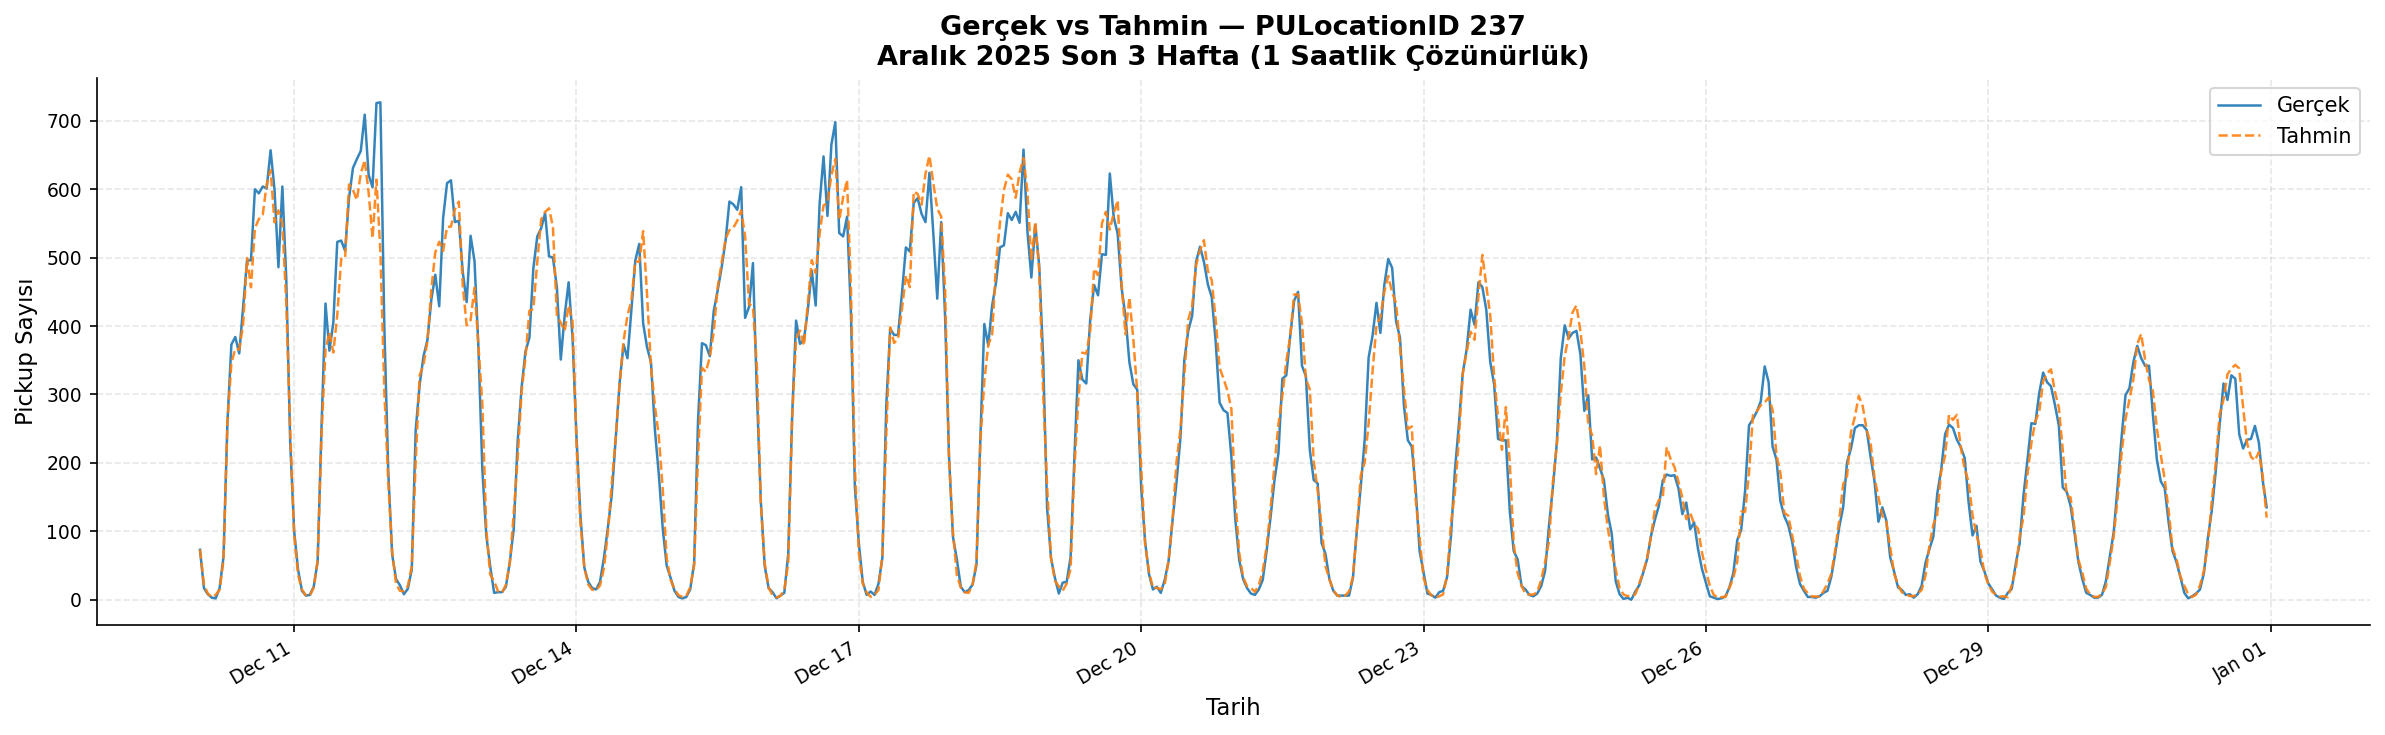

20:41:49  Grafik kaydedildi → actual_vs_predicted_dec2025.png


In [ ]:
# ---------------------------------------------------------------------------
# 5-B  Actual vs Predicted — en yoğun PULocationID
#       X ekseni: Aralık 2025'in son 3 haftası (okunabilirlik için)
# ---------------------------------------------------------------------------
test_df_copy          = test_df.copy()
test_df_copy["y_pred"] = y_pred_test

busiest_loc = (
    test_df_copy
    .groupby("PULocationID")[TARGET_COL]
    .sum()
    .idxmax()
)
log.info("En yoğun PULocationID (test dönemi): %d", busiest_loc)

loc_df = (
    test_df_copy[test_df_copy["PULocationID"] == busiest_loc]
    .copy()
    .sort_values("time_bin")
)

# Son 3 hafta filtresi
plot_start = pd.Timestamp("2025-12-10 00:00:00")
plot_end   = pd.Timestamp("2025-12-31 23:00:00")
plot_df = loc_df[
    (loc_df["time_bin"] >= plot_start) & (loc_df["time_bin"] <= plot_end)
]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(
    plot_df["time_bin"], plot_df[TARGET_COL],
    label="Gerçek", color="#1f77b4", linewidth=1.2, alpha=0.9,
)
ax.plot(
    plot_df["time_bin"], plot_df["y_pred"],
    label="Tahmin", color="#ff7f0e", linewidth=1.2,
    linestyle="--", alpha=0.9,
)
ax.set_title(
    f"Gerçek vs Tahmin — PULocationID {busiest_loc}\n"
    "Aralık 2025 Son 3 Hafta (1 Saatlik Çözünürlük)",
    fontsize=13, fontweight="bold",
)
ax.set_xlabel("Tarih", fontsize=11)
ax.set_ylabel("Pickup Sayısı", fontsize=11)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
fig.autofmt_xdate(rotation=30)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("actual_vs_predicted_dec2025.png", dpi=150, bbox_inches="tight")
plt.show()
log.info("Grafik kaydedildi → actual_vs_predicted_dec2025.png")

20:41:49  SHAP değerleri hesaplanıyor (5000 satır örneklem) …


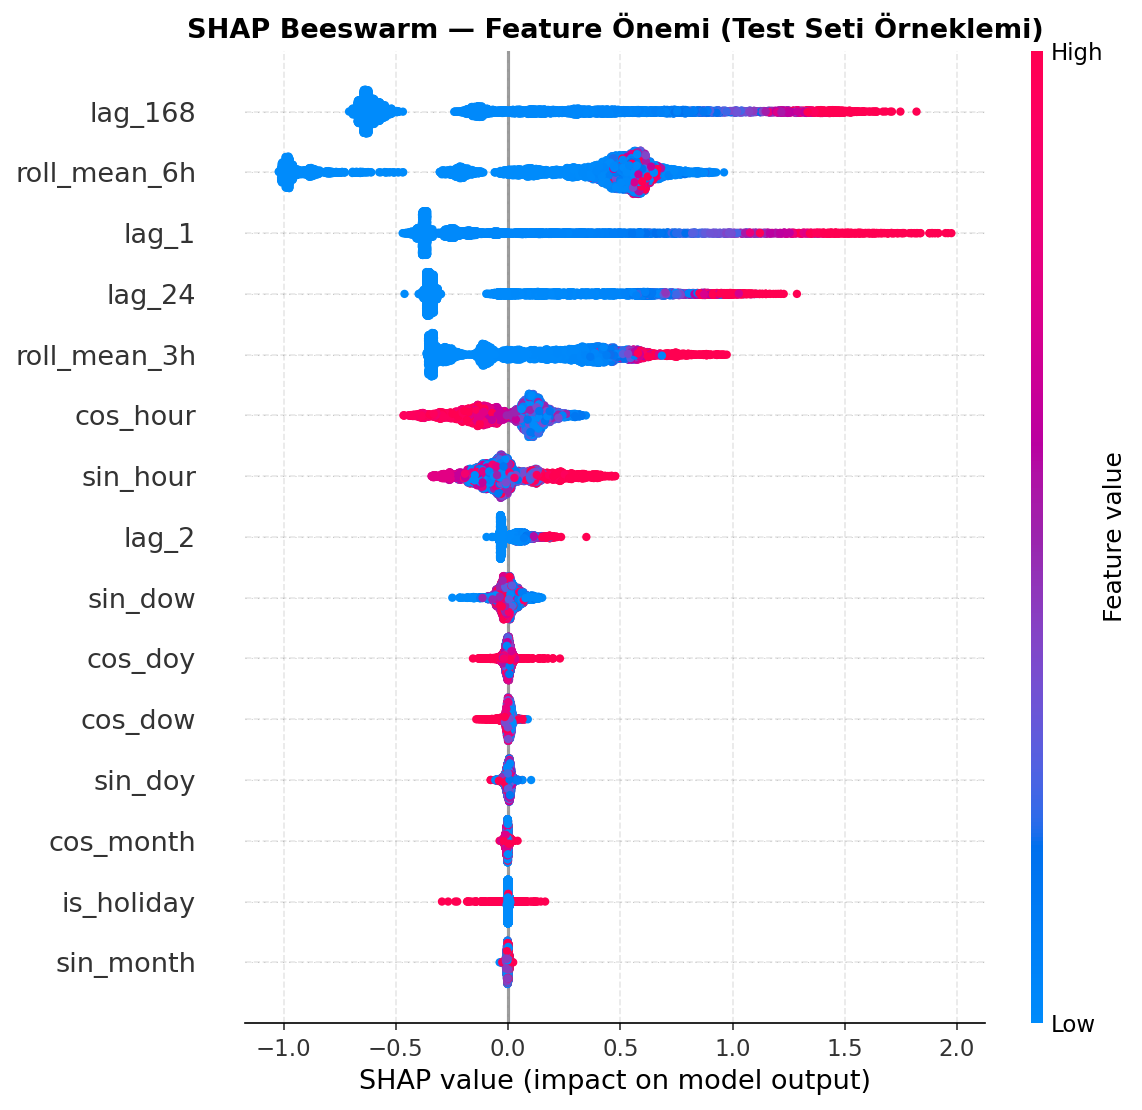

20:47:21  SHAP grafiği kaydedildi → shap_beeswarm.png


In [ ]:
# ---------------------------------------------------------------------------
# 5-C  SHAP Beeswarm Plot
#       Test setinden 5.000 satır rastgele örneklem → aşırı hesap yükü önlenir
# ---------------------------------------------------------------------------
SHAP_SAMPLE = 5_000

rng         = np.random.default_rng(SEED)
sample_idx  = rng.choice(
    len(X_test), size=min(SHAP_SAMPLE, len(X_test)), replace=False
)
X_test_shap = X_test.iloc[sample_idx].reset_index(drop=True)

log.info("SHAP değerleri hesaplanıyor (%d satır örneklem) …", len(X_test_shap))

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_shap)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_shap,
    plot_type="dot",    # beeswarm
    max_display=20,
    show=False,
)
plt.title(
    "SHAP Beeswarm — Feature Önemi (Test Seti Örneklemi)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
log.info("SHAP grafiği kaydedildi → shap_beeswarm.png")

In [ ]:
# ---------------------------------------------------------------------------
# 5-D  En yoğun 10 lokasyon için RMSE / MAE özeti
# ---------------------------------------------------------------------------
test_df_copy["sq_err"]  = (test_df_copy[TARGET_COL] - test_df_copy["y_pred"]) ** 2
test_df_copy["abs_err"] = (test_df_copy[TARGET_COL] - test_df_copy["y_pred"]).abs()

per_loc = (
    test_df_copy
    .groupby("PULocationID")
    .agg(
        total_actual = (TARGET_COL, "sum"),
        rmse         = ("sq_err",  lambda x: np.sqrt(x.mean())),
        mae          = ("abs_err", "mean"),
    )
    .sort_values("total_actual", ascending=False)
    .head(10)
    .reset_index()
)

print("\nEn yoğun 10 lokasyon — Test dönemi metrikleri")
print(per_loc.to_string(index=False))


En yoğun 10 lokasyon — Test dönemi metrikleri
 PULocationID  total_actual      rmse       mae
          237        567323 34.349491 23.176522
          161        510453 38.150301 24.824833
          236        497581 32.865935 21.675664
          132        490784 50.098995 35.644435
          186        380289 38.853209 26.611969
          162        378004 26.600303 18.240022
          142        367722 41.262639 24.155641
          230        356858 30.351033 20.524218
          138        328950 48.342272 31.873764
          234        315990 21.220996 14.646377


In [ ]:
# ---------------------------------------------------------------------------
# 5-E  Final model kaydet
# ---------------------------------------------------------------------------
final_model.save_model("lgbm_nyc_taxi_spatiotemporal.txt")
log.info("Model kaydedildi → lgbm_nyc_taxi_spatiotemporal.txt")

print("\n✓ Pipeline tamamlandı.")
print(f"  RMSE  = {rmse:.4f}")
print(f"  MAE   = {mae:.4f}")
print(f"  MAPE  = {mape:.2f}%")

20:47:21  Model kaydedildi → lgbm_nyc_taxi_spatiotemporal.txt



✓ Pipeline tamamlandı.
  RMSE  = 9.8185
  MAE   = 3.3944
  MAPE  = 45.57%


  NYC Taxi Spatiotemporal Analysis — Generating Figures

[1/6] Annual & Monthly Trend...


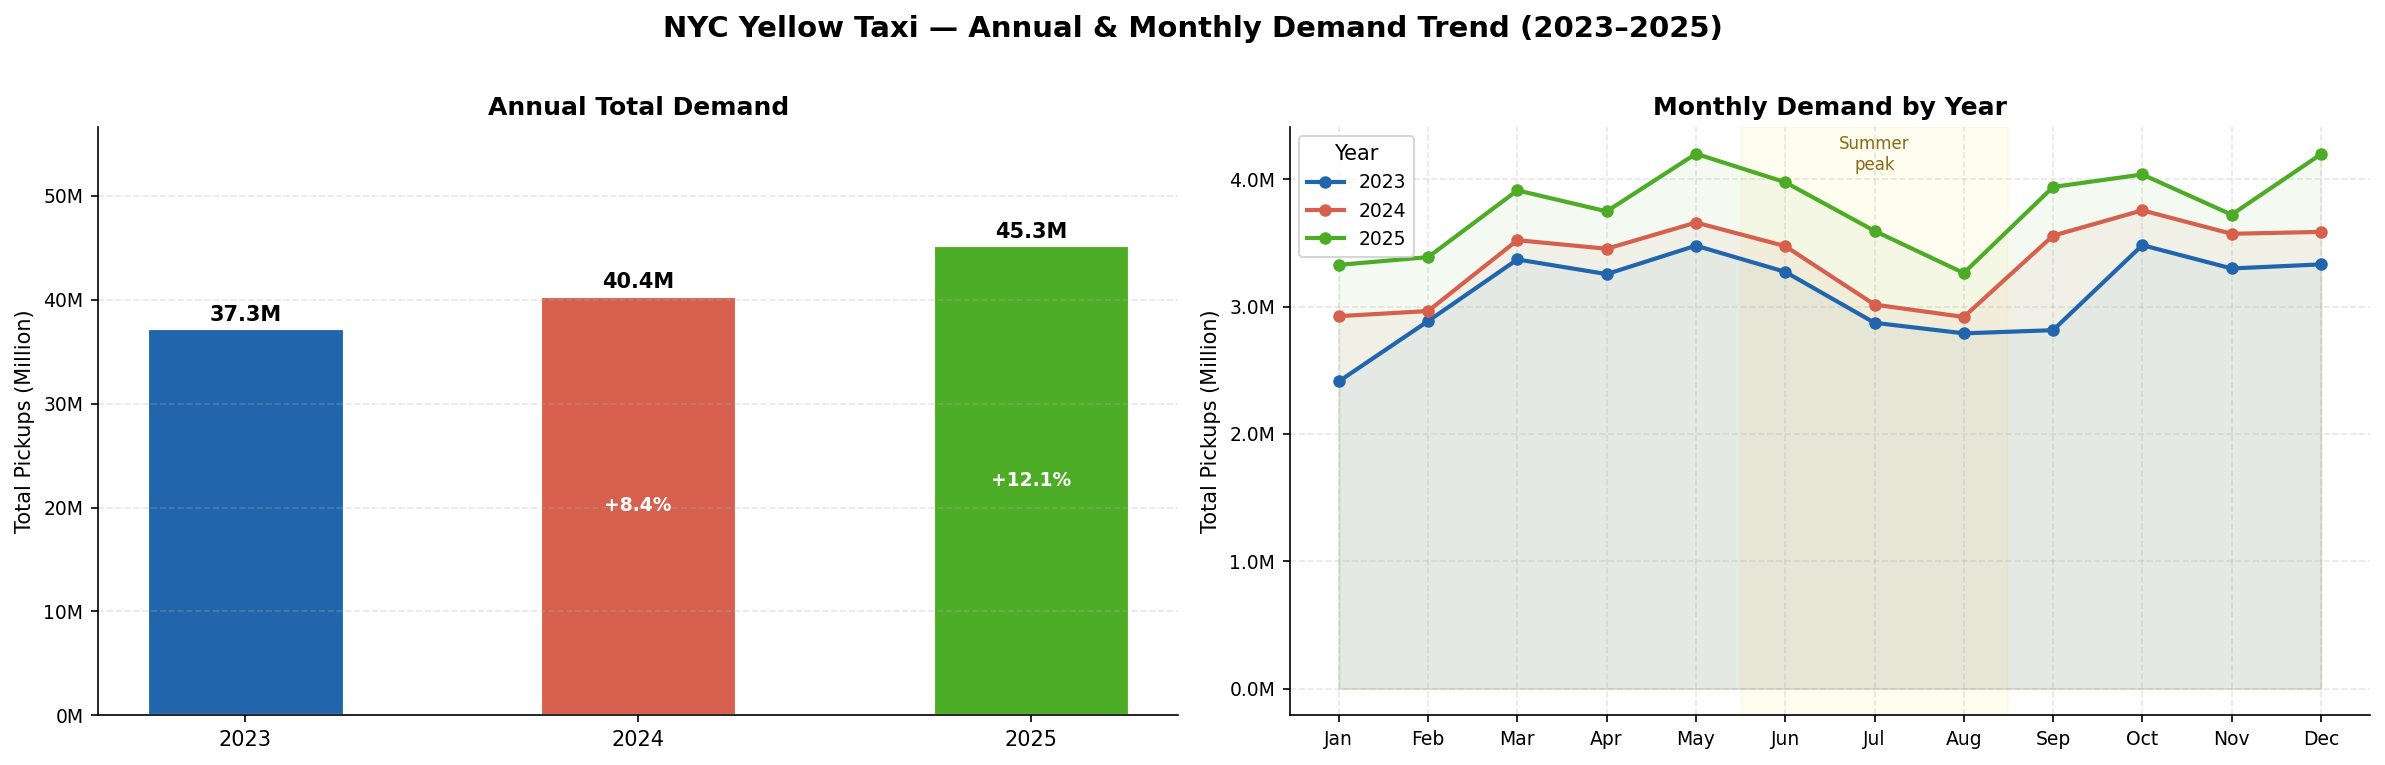

  Saved → /kaggle/working/fig1_annual_monthly_trend.png

[2/6] Seasonal Heatmap...


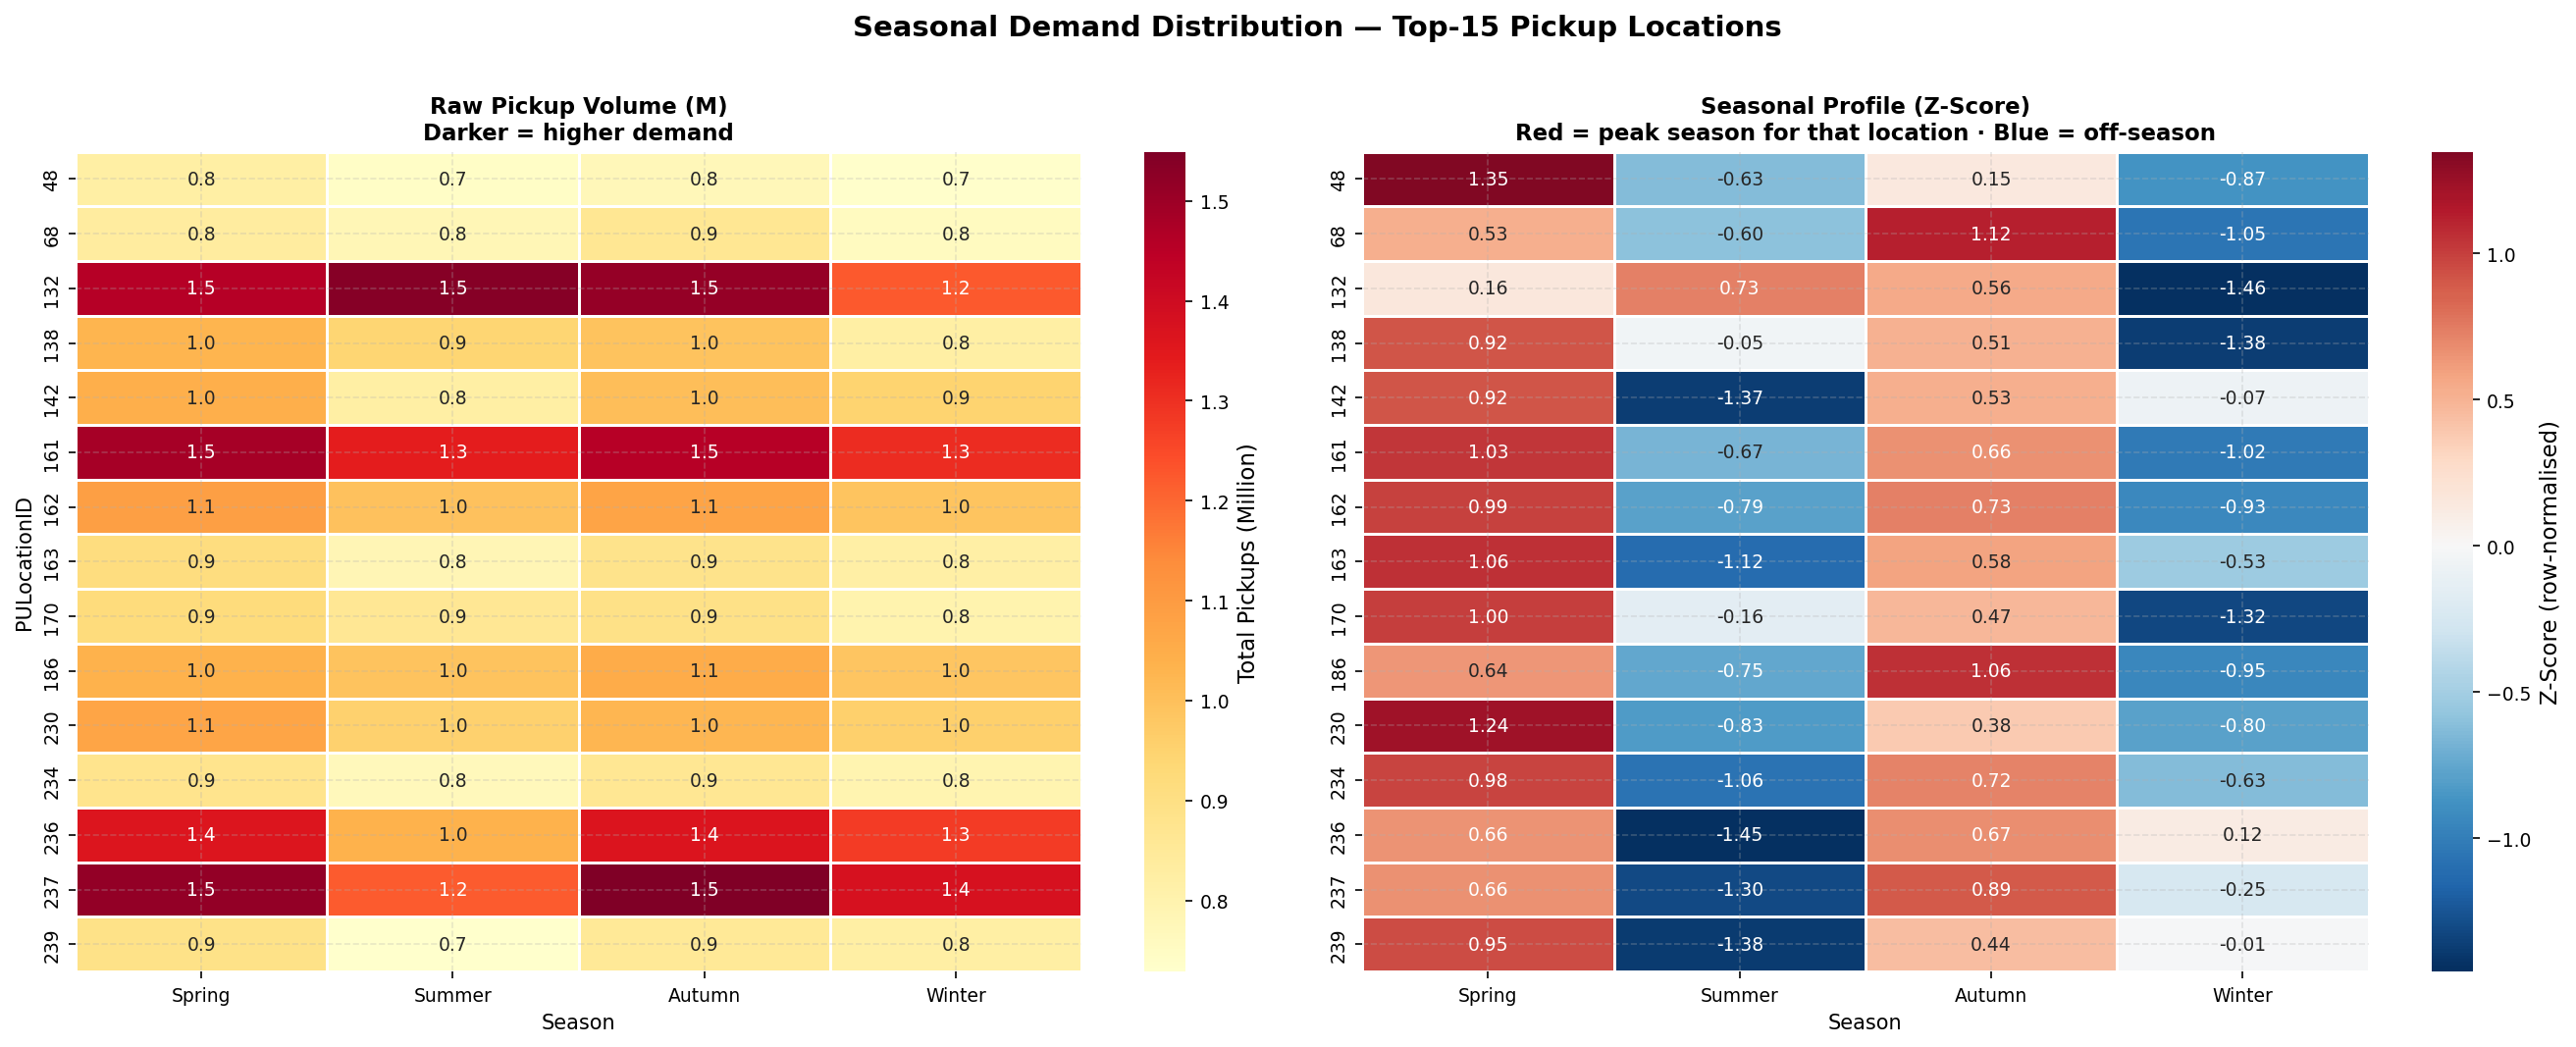

  Saved → /kaggle/working/fig2_seasonal_heatmap.png

[3/6] Weekly Distribution...


20:47:27  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
20:47:27  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
20:47:27  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
20:47:27  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
20:47:27  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


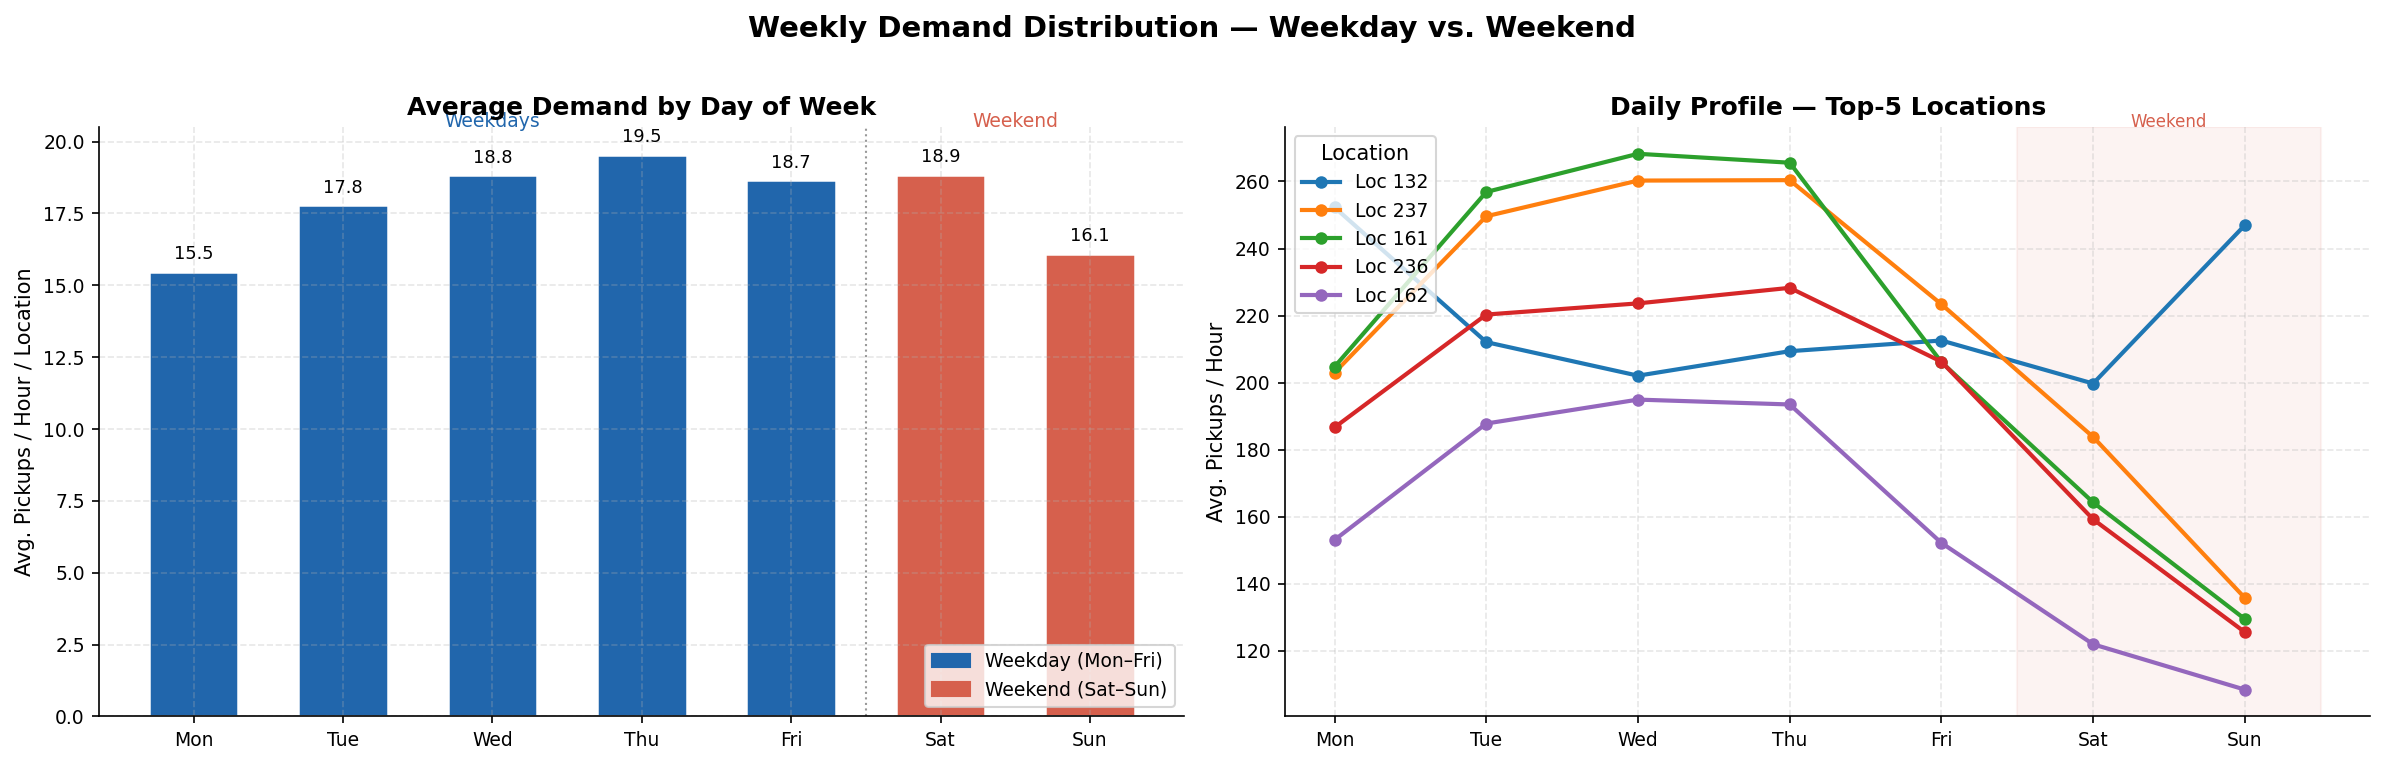

  Saved → /kaggle/working/fig3_weekly_distribution.png

[4/6] Hourly Peak Analysis...


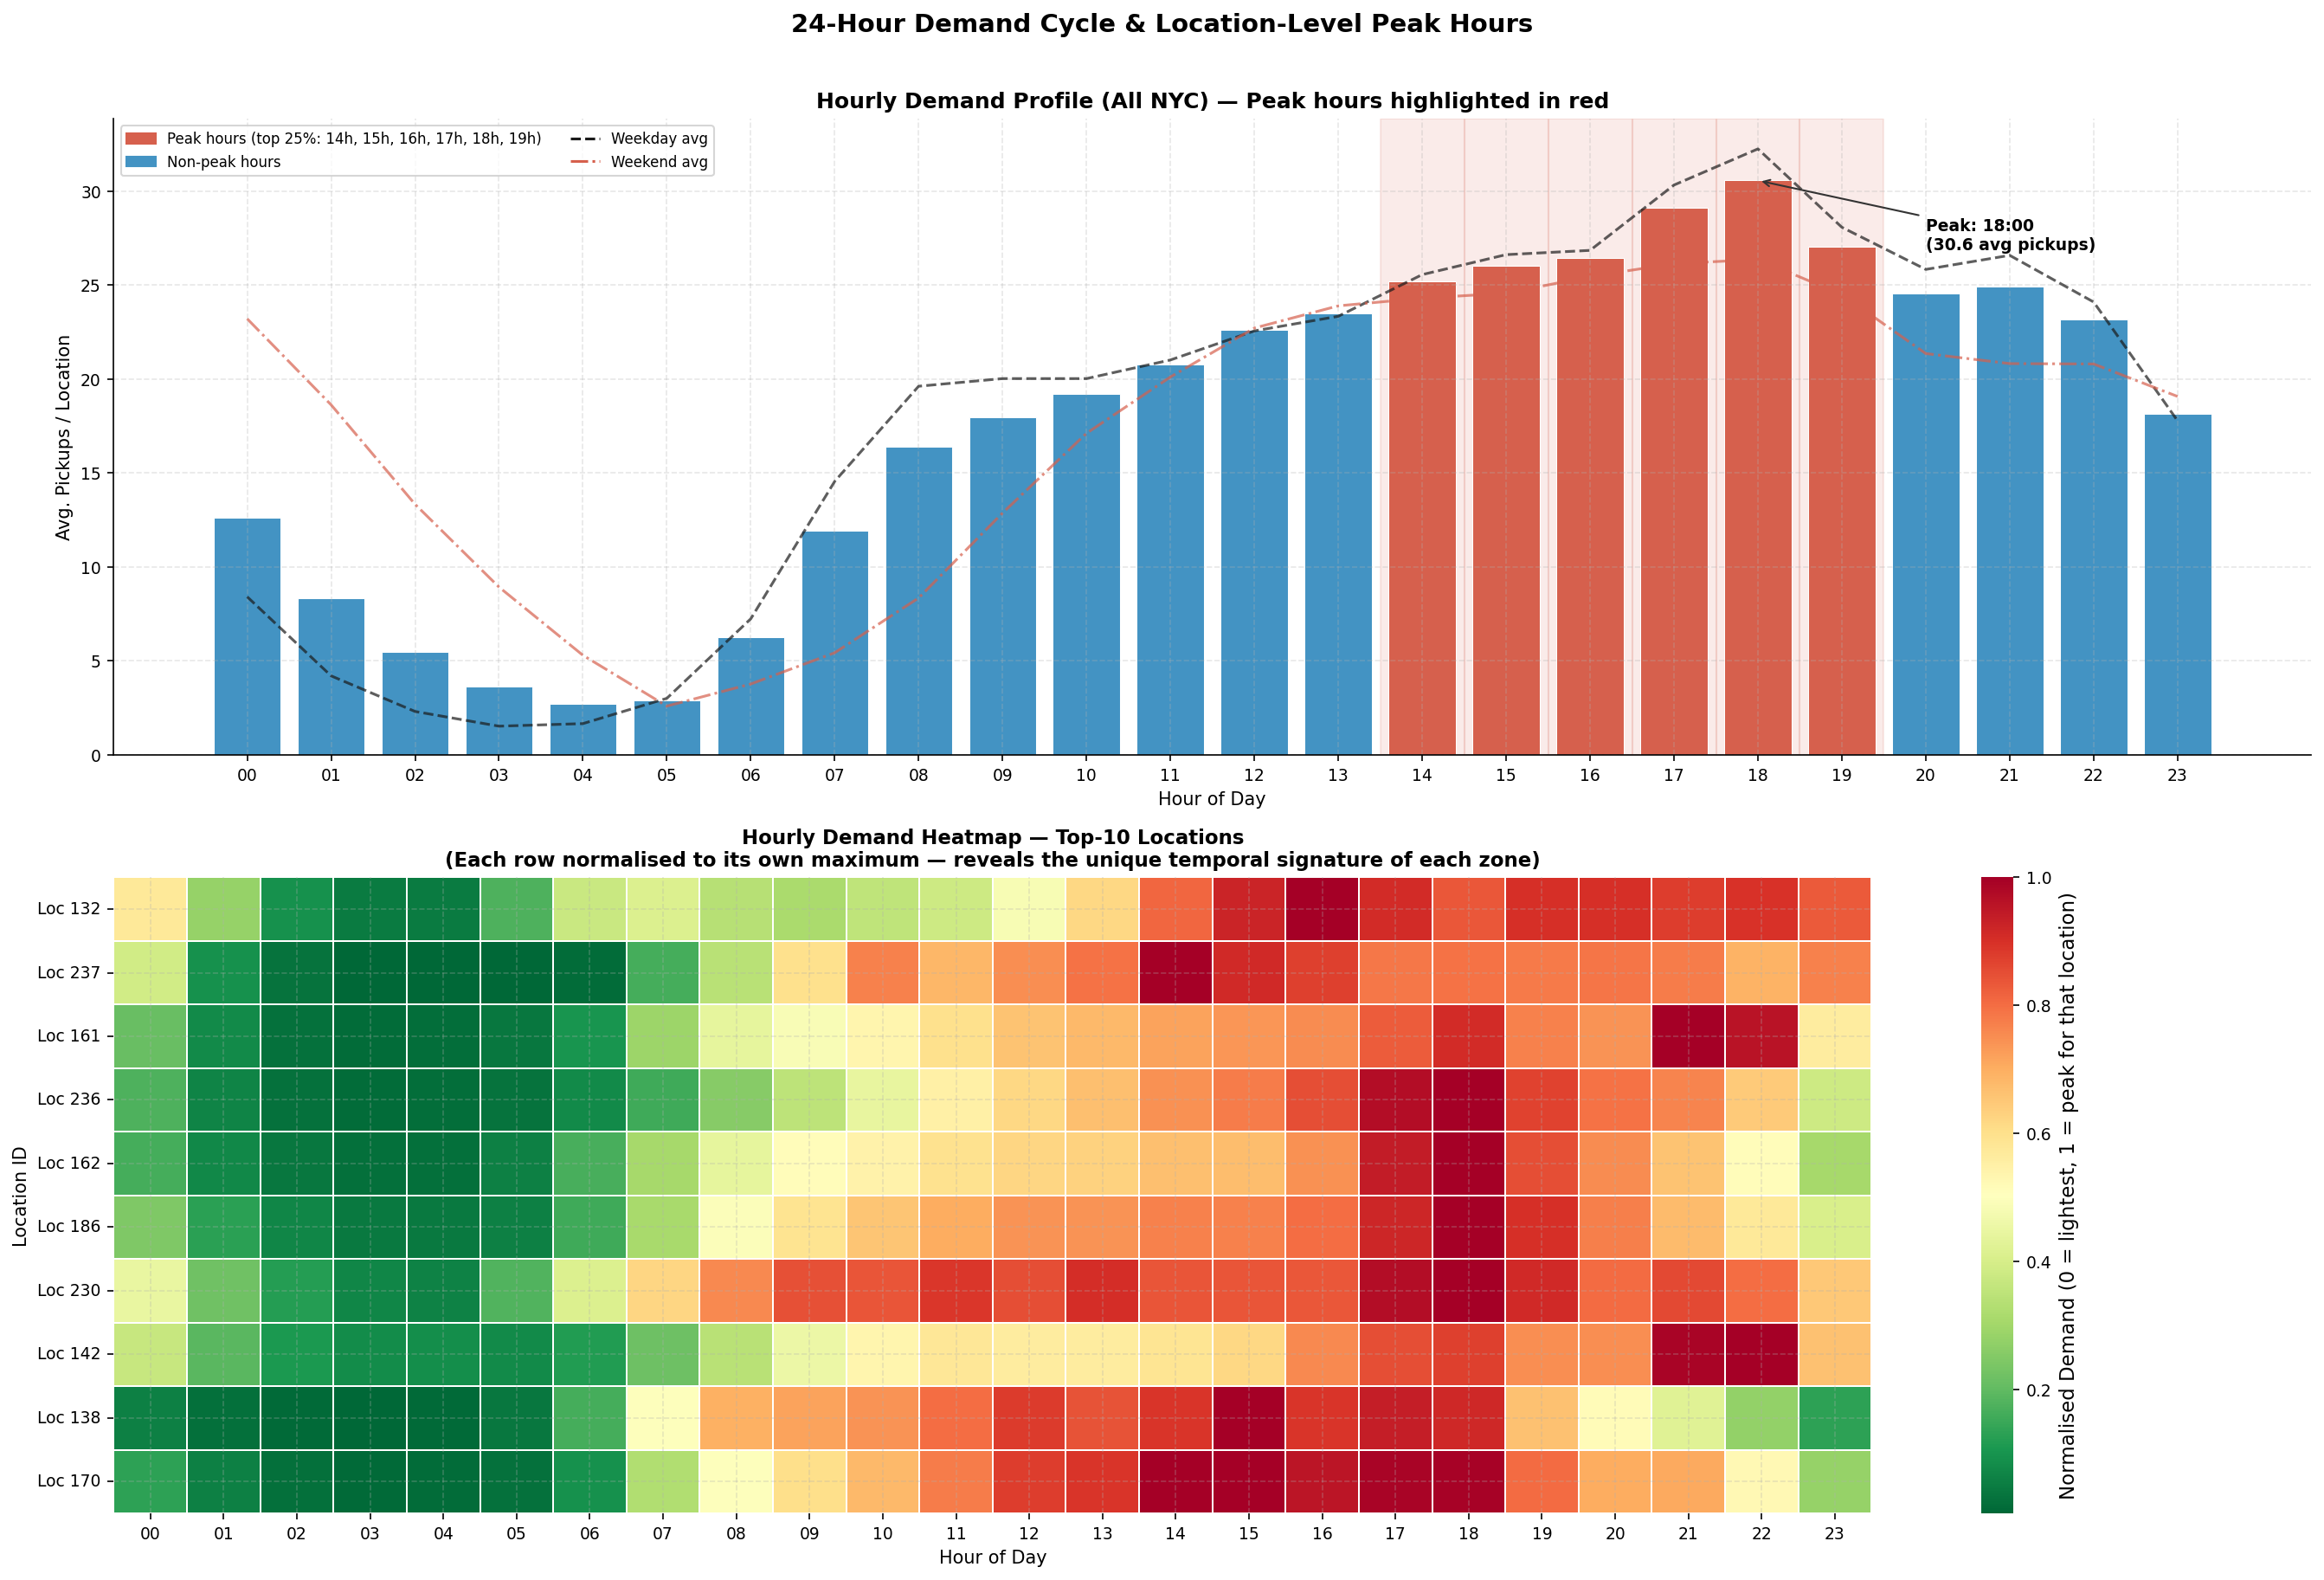

  Saved → /kaggle/working/fig4_hourly_peak_analysis.png

[5/6] Day × Hour Heatmap...


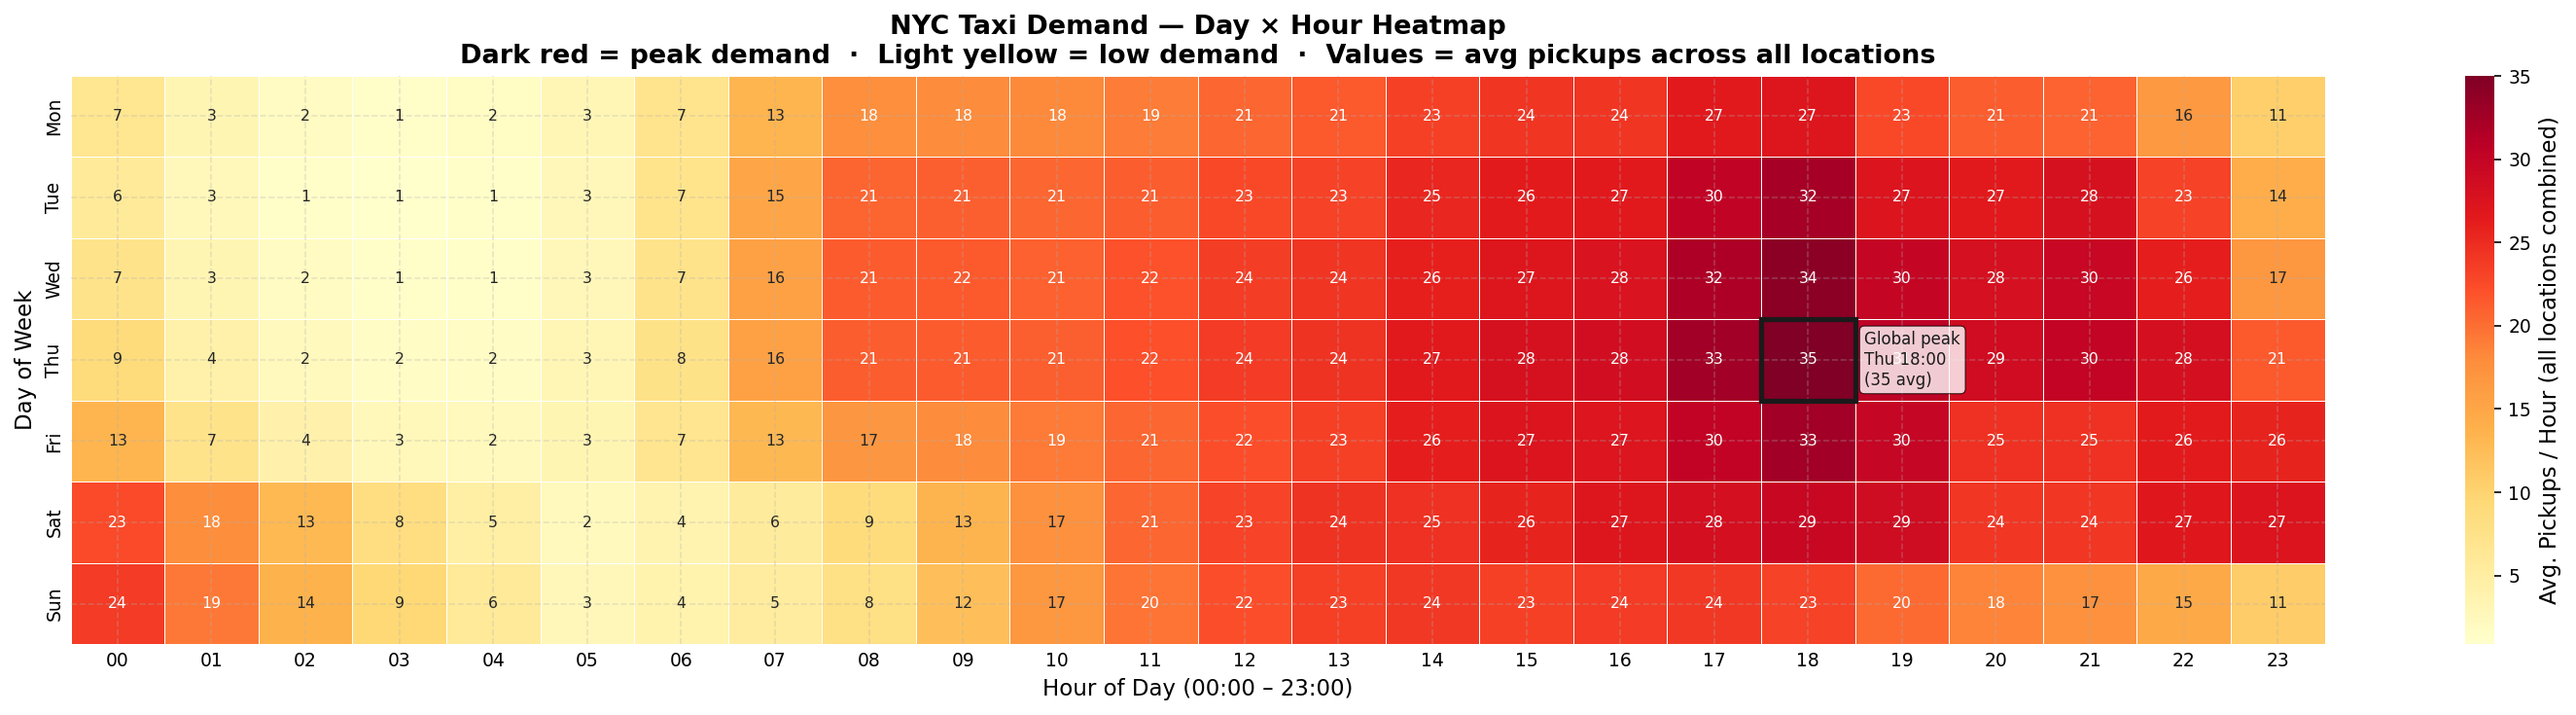

  Saved → /kaggle/working/fig5_day_hour_heatmap.png

[6/6] Top-10 Location Performance...


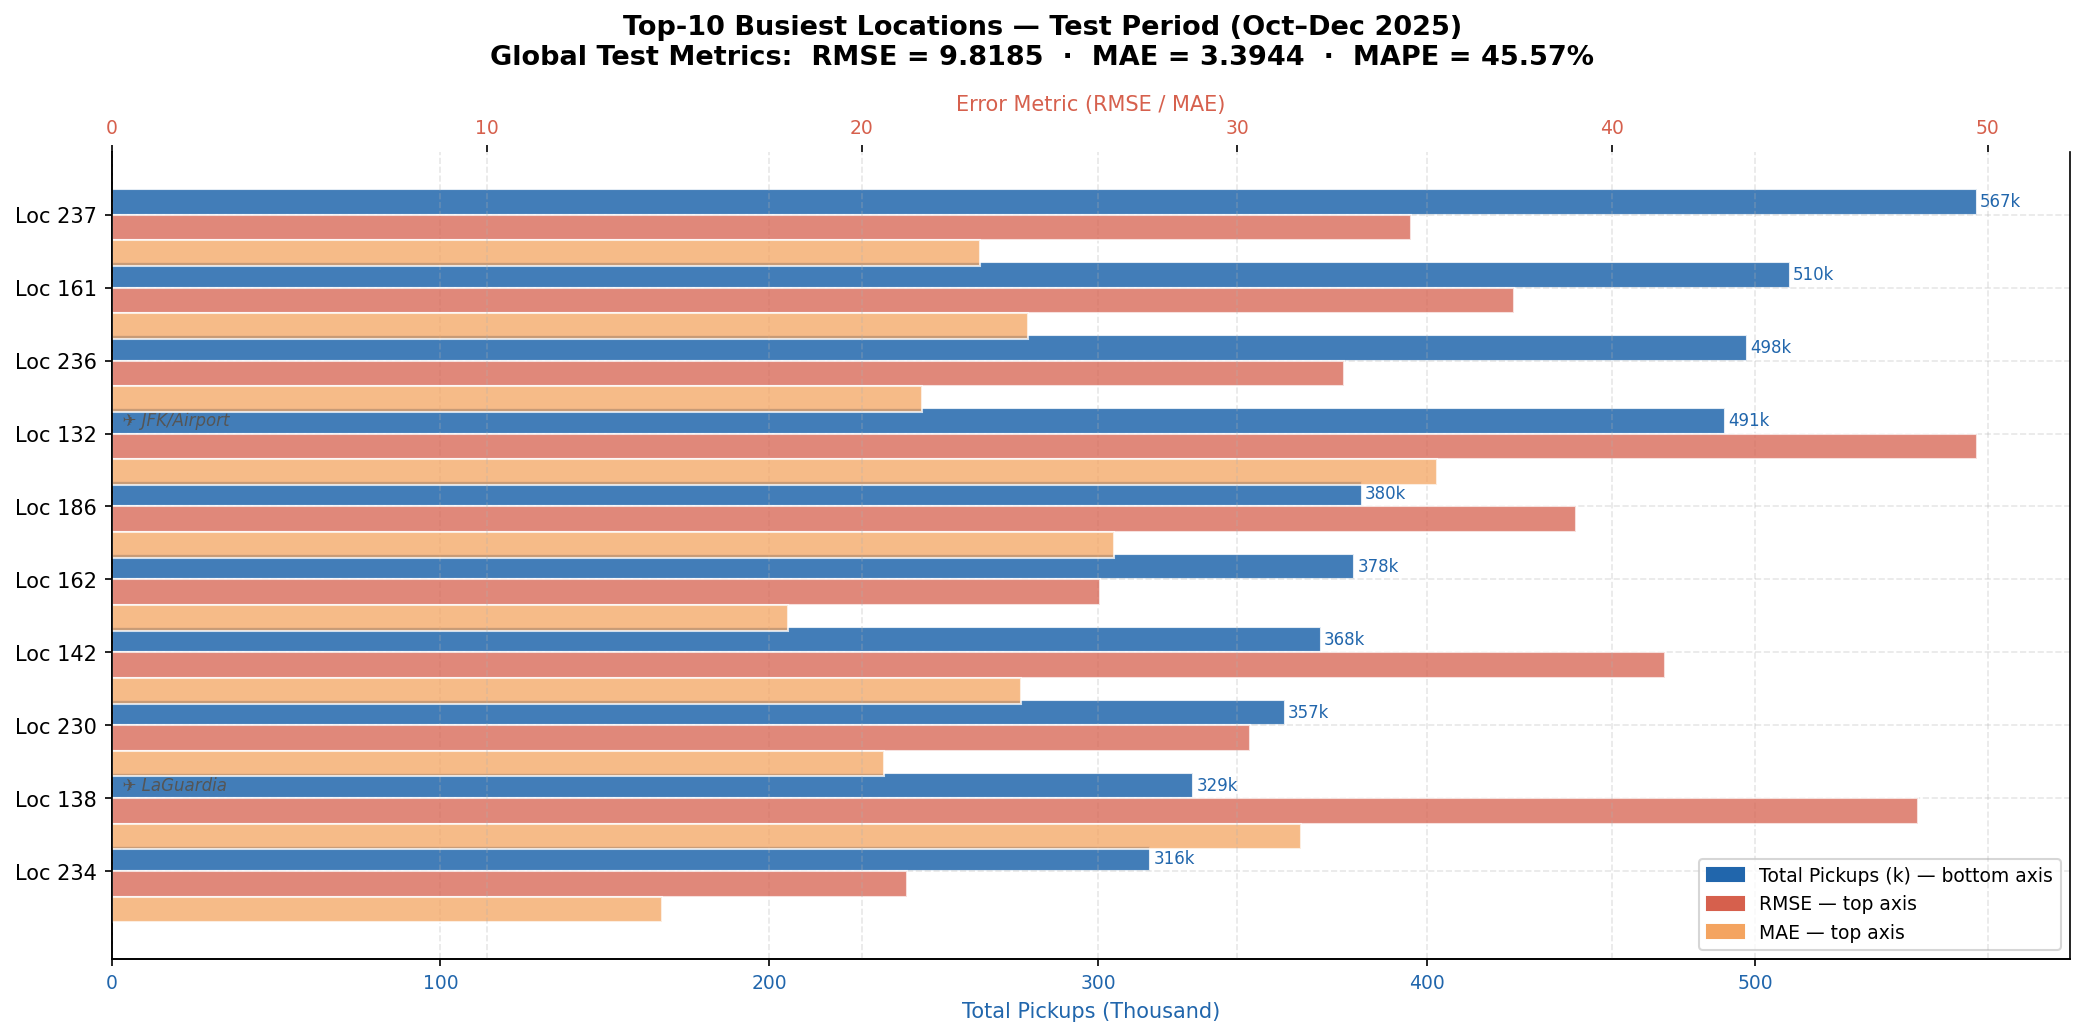

  Saved → /kaggle/working/fig6_top10_location_performance.png

  All figures saved to: /kaggle/working
  Files:
    1. fig1_annual_monthly_trend.png
    2. fig2_seasonal_heatmap.png
    3. fig3_weekly_distribution.png
    4. fig4_hourly_peak_analysis.png
    5. fig5_day_hour_heatmap.png
    6. fig6_top10_location_performance.png


In [ ]:
# =============================================================================
# NYC Yellow Taxi (2023-2025) — Spatiotemporal Demand Analysis
# Visualization Suite — Publication-Ready Figures
#
# Usage: Run AFTER your main pipeline notebook.
#        All variables (feat_df, test_df_copy, rmse, mae, mape) must be in scope.
#        Or run standalone using the STANDALONE MODE block at the bottom.
#
# Output: 6 high-resolution PNG files saved to /kaggle/working/
#   1. fig1_annual_monthly_trend.png
#   2. fig2_seasonal_heatmap.png
#   3. fig3_weekly_distribution.png
#   4. fig4_hourly_peak_analysis.png
#   5. fig5_day_hour_heatmap.png
#   6. fig6_top10_location_performance.png
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# -----------------------------------------------------------------------------
# Global Style Configuration
# -----------------------------------------------------------------------------
plt.rcParams.update({
    "figure.dpi"        : 150,
    "savefig.dpi"       : 200,
    "savefig.bbox"      : "tight",
    "savefig.facecolor" : "white",
    "font.family"       : "DejaVu Sans",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "grid.linestyle"    : "--",
    "axes.titlesize"    : 13,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 11,
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
    "legend.fontsize"   : 9,
    "legend.framealpha" : 0.8,
})

# Color palette (colorblind-friendly)
C2023   = "#2166AC"   # Blue
C2024   = "#D6604D"   # Red-orange
C2025   = "#4DAC26"   # Green
CPEAK   = "#D6604D"   # Peak highlight
CNORMAL = "#4393C3"   # Normal bars
CWKDAY  = "#2166AC"   # Weekday
CWKEND  = "#D6604D"   # Weekend

MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
DAY_LABELS   = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

OUT_DIR = Path("/kaggle/working")

# =============================================================================
# SECTION 0 — Build Analysis DataFrame from feat_df
# =============================================================================
def build_analysis_df(feat_df: pd.DataFrame) -> pd.DataFrame:
    """Extract temporal features needed for all plots."""
    df = feat_df[["PULocationID", "time_bin", "pickup_count"]].copy()
    df["year"]       = df["time_bin"].dt.year
    df["month"]      = df["time_bin"].dt.month
    df["hour"]       = df["time_bin"].dt.hour
    df["dow"]        = df["time_bin"].dt.dayofweek   # 0=Monday
    df["is_weekend"] = (df["dow"] >= 5).astype(int)

    def _season(m):
        if m in [3, 4, 5]:   return "Spring"
        elif m in [6, 7, 8]: return "Summer"
        elif m in [9,10,11]: return "Autumn"
        else:                return "Winter"

    df["season"] = df["month"].apply(_season)
    return df


# =============================================================================
# FIGURE 1 — Annual & Monthly Trend
# =============================================================================
def plot_annual_monthly_trend(adf: pd.DataFrame, out_dir: Path) -> None:
    # --- Data aggregation ---
    yearly  = adf.groupby("year")["pickup_count"].sum() / 1e6      # millions
    monthly = (
        adf.groupby(["year", "month"])["pickup_count"]
        .sum()
        .reset_index()
    )
    monthly["pickup_M"] = monthly["pickup_count"] / 1e6

    years      = sorted(adf["year"].unique())
    year_colors = {2023: C2023, 2024: C2024, 2025: C2025}

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(
        "NYC Yellow Taxi — Annual & Monthly Demand Trend (2023–2025)",
        fontsize=14, fontweight="bold", y=1.01,
    )

    # --- LEFT: Annual bar chart ---
    ax = axes[0]
    x_pos   = np.arange(len(years))
    bar_col = [year_colors.get(y, "#888888") for y in years]
    bars    = ax.bar(x_pos, yearly.values, color=bar_col,
                     width=0.5, edgecolor="white", linewidth=1.5)

    for bar, val in zip(bars, yearly.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{val:.1f}M",
            ha="center", va="bottom", fontsize=10, fontweight="bold",
        )

    # YoY change annotation
    vals = yearly.values
    for i in range(1, len(vals)):
        chg = (vals[i] - vals[i-1]) / vals[i-1] * 100
        sign = "+" if chg > 0 else ""
        ax.annotate(
            f"{sign}{chg:.1f}%",
            xy=(i, vals[i] / 2),
            ha="center", va="center", fontsize=9,
            color="white", fontweight="bold",
        )

    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(y) for y in years], fontsize=10)
    ax.set_ylabel("Total Pickups (Million)", fontsize=10)
    ax.set_title("Annual Total Demand", fontsize=12, fontweight="bold")
    ax.set_ylim(0, yearly.max() * 1.25)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0fM"))
    ax.grid(axis="x", alpha=0)

    # --- RIGHT: Monthly line chart ---
    ax = axes[1]
    for year in years:
        sub = monthly[monthly["year"] == year].sort_values("month")
        ax.plot(
            sub["month"], sub["pickup_M"],
            marker="o", markersize=5, linewidth=2,
            label=str(year), color=year_colors.get(year, "#888888"),
        )
        # Shade area under curve lightly
        ax.fill_between(
            sub["month"], sub["pickup_M"],
            alpha=0.06, color=year_colors.get(year, "#888888"),
        )

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_LABELS)
    ax.set_ylabel("Total Pickups (Million)", fontsize=10)
    ax.set_title("Monthly Demand by Year", fontsize=12, fontweight="bold")
    ax.legend(title="Year", framealpha=0.8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1fM"))

    # Annotate summer peak
    ax.axvspan(5.5, 8.5, alpha=0.06, color="gold", zorder=0)
    ax.text(7, monthly["pickup_M"].max() * 0.97, "Summer\npeak",
            ha="center", fontsize=8, color="#8B6914")

    plt.tight_layout()
    fpath = out_dir / "fig1_annual_monthly_trend.png"
    fig.savefig(fpath)
    plt.show()
    print(f"  Saved → {fpath}")


# =============================================================================
# FIGURE 2 — Seasonal Heatmap (Top-15 Locations)
# =============================================================================
def plot_seasonal_heatmap(adf: pd.DataFrame, out_dir: Path) -> None:
    SEASON_ORDER = ["Spring", "Summer", "Autumn", "Winter"]
    top15 = (
        adf.groupby("PULocationID")["pickup_count"]
        .sum().sort_values(ascending=False)
        .head(15).index.tolist()
    )

    pivot = pd.pivot_table(
        adf[adf["PULocationID"].isin(top15)],
        values="pickup_count",
        index="PULocationID",
        columns="season",
        aggfunc="sum",
    )[SEASON_ORDER] / 1e6   # millions

    zscore = pivot.apply(
        lambda row: (row - row.mean()) / (row.std() + 1e-9), axis=1
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(
        "Seasonal Demand Distribution — Top-15 Pickup Locations",
        fontsize=14, fontweight="bold", y=1.01,
    )

    # Left: raw
    sns.heatmap(
        pivot, ax=axes[0],
        cmap="YlOrRd", annot=True, fmt=".1f",
        linewidths=0.5, linecolor="white",
        cbar_kws={"label": "Total Pickups (Million)"},
        annot_kws={"size": 9},
    )
    axes[0].set_title(
        "Raw Pickup Volume (M)\nDarker = higher demand",
        fontsize=11, fontweight="bold",
    )
    axes[0].set_ylabel("PULocationID", fontsize=10)
    axes[0].set_xlabel("Season", fontsize=10)

    # Right: z-score
    sns.heatmap(
        zscore, ax=axes[1],
        cmap="RdBu_r", center=0, annot=True, fmt=".2f",
        linewidths=0.5, linecolor="white",
        cbar_kws={"label": "Z-Score (row-normalised)"},
        annot_kws={"size": 9},
    )
    axes[1].set_title(
        "Seasonal Profile (Z-Score)\nRed = peak season for that location · Blue = off-season",
        fontsize=11, fontweight="bold",
    )
    axes[1].set_ylabel("", fontsize=10)
    axes[1].set_xlabel("Season", fontsize=10)

    plt.tight_layout()
    fpath = out_dir / "fig2_seasonal_heatmap.png"
    fig.savefig(fpath)
    plt.show()
    print(f"  Saved → {fpath}")


# =============================================================================
# FIGURE 3 — Weekly Distribution (Weekday vs. Weekend)
# =============================================================================
def plot_weekly_distribution(adf: pd.DataFrame, out_dir: Path) -> None:
    top5 = (
        adf.groupby("PULocationID")["pickup_count"]
        .sum().sort_values(ascending=False)
        .head(5).index.tolist()
    )

    daily_avg = (
        adf.groupby("dow")["pickup_count"]
        .mean().reset_index().sort_values("dow")
    )

    dow_loc = (
        adf[adf["PULocationID"].isin(top5)]
        .groupby(["PULocationID", "dow"])["pickup_count"]
        .mean().reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(
        "Weekly Demand Distribution — Weekday vs. Weekend",
        fontsize=14, fontweight="bold", y=1.01,
    )

    # --- LEFT: Bar chart ---
    ax = axes[0]
    colors = [CWKDAY if d < 5 else CWKEND for d in range(7)]
    bars = ax.bar(
        DAY_LABELS, daily_avg["pickup_count"].values,
        color=colors, edgecolor="white", linewidth=1.2, width=0.6,
    )

    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{bar.get_height():.1f}",
            ha="center", va="bottom", fontsize=8.5,
        )

    ax.axvline(x=4.5, color="#999", linewidth=1, linestyle=":")
    ax.text(2.0, daily_avg["pickup_count"].max() * 1.05,
            "Weekdays", ha="center", fontsize=9, color=CWKDAY)
    ax.text(5.5, daily_avg["pickup_count"].max() * 1.05,
            "Weekend", ha="center", fontsize=9, color=CWKEND)

    legend_patches = [
        mpatches.Patch(color=CWKDAY, label="Weekday (Mon–Fri)"),
        mpatches.Patch(color=CWKEND, label="Weekend (Sat–Sun)"),
    ]
    ax.legend(handles=legend_patches, loc="lower right")
    ax.set_ylabel("Avg. Pickups / Hour / Location", fontsize=10)
    ax.set_title("Average Demand by Day of Week", fontsize=12, fontweight="bold")

    # --- RIGHT: Line chart per top-5 location ---
    ax = axes[1]
    palette = sns.color_palette("tab10", n_colors=5)
    for i, loc in enumerate(top5):
        sub = dow_loc[dow_loc["PULocationID"] == loc].sort_values("dow")
        ax.plot(
            DAY_LABELS, sub["pickup_count"].values,
            marker="o", markersize=5, linewidth=2,
            label=f"Loc {loc}", color=palette[i],
        )

    ax.axvspan(4.5, 6.5, alpha=0.07, color="#D6604D", zorder=0)
    ax.text(5.5, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 100,
            "Weekend", ha="center", fontsize=8, color="#D6604D")
    ax.set_ylabel("Avg. Pickups / Hour", fontsize=10)
    ax.set_title("Daily Profile — Top-5 Locations", fontsize=12, fontweight="bold")
    ax.legend(title="Location", loc="upper left")

    plt.tight_layout()
    fpath = out_dir / "fig3_weekly_distribution.png"
    fig.savefig(fpath)
    plt.show()
    print(f"  Saved → {fpath}")


# =============================================================================
# FIGURE 4 — Hourly Peak Analysis (24-hour Cycle)
# =============================================================================
def plot_hourly_peak_analysis(adf: pd.DataFrame, out_dir: Path) -> None:
    top10 = (
        adf.groupby("PULocationID")["pickup_count"]
        .sum().sort_values(ascending=False)
        .head(10).index.tolist()
    )

    hourly_all     = adf.groupby("hour")["pickup_count"].mean()
    hourly_weekday = adf[adf["is_weekend"]==0].groupby("hour")["pickup_count"].mean()
    hourly_weekend = adf[adf["is_weekend"]==1].groupby("hour")["pickup_count"].mean()

    peak_threshold = hourly_all.quantile(0.75)
    peak_hours     = hourly_all[hourly_all >= peak_threshold].index.tolist()

    loc_hour_pivot = pd.pivot_table(
        adf[adf["PULocationID"].isin(top10)],
        values="pickup_count",
        index="PULocationID",
        columns="hour",
        aggfunc="mean",
    )
    loc_hour_norm = loc_hour_pivot.div(loc_hour_pivot.max(axis=1), axis=0)
    hour_labels = [f"{h:02d}" for h in range(24)]

    fig, axes = plt.subplots(2, 1, figsize=(18, 12))
    fig.suptitle(
        "24-Hour Demand Cycle & Location-Level Peak Hours",
        fontsize=14, fontweight="bold", y=1.01,
    )

    # --- TOP: 24-hour bar chart ---
    ax = axes[0]
    bar_colors = [CPEAK if h in peak_hours else CNORMAL for h in range(24)]
    bars = ax.bar(
        range(24), hourly_all.values,
        color=bar_colors, edgecolor="white", linewidth=0.5,
    )

    ax.plot(range(24), hourly_weekday.values,
            color="#1A1A1A", linewidth=1.5, linestyle="--",
            label="Weekday avg", alpha=0.7)
    ax.plot(range(24), hourly_weekend.values,
            color="#D6604D", linewidth=1.5, linestyle="-.",
            label="Weekend avg", alpha=0.7)

    for ph in peak_hours:
        ax.axvspan(ph - 0.5, ph + 0.5, alpha=0.12, color="#D6604D", zorder=0)

    peak_h = int(hourly_all.idxmax())
    ax.annotate(
        f"Peak: {peak_h:02d}:00\n({hourly_all[peak_h]:.1f} avg pickups)",
        xy=(peak_h, hourly_all[peak_h]),
        xytext=(peak_h + 2, hourly_all[peak_h] * 0.88),
        arrowprops=dict(arrowstyle="->", color="#333"),
        fontsize=9, fontweight="bold",
    )

    ax.set_xticks(range(24))
    ax.set_xticklabels(hour_labels)
    ax.set_ylabel("Avg. Pickups / Location", fontsize=10)
    ax.set_xlabel("Hour of Day", fontsize=10)
    ax.set_title(
        "Hourly Demand Profile (All NYC) — Peak hours highlighted in red",
        fontsize=12, fontweight="bold",
    )
    legend_patches = [
        mpatches.Patch(color=CPEAK,   label=f"Peak hours (top 25%: {', '.join(f'{h:02d}h' for h in sorted(peak_hours))})"),
        mpatches.Patch(color=CNORMAL, label="Non-peak hours"),
    ]
    ax.legend(
        handles=legend_patches + [
            plt.Line2D([0],[0], color="#1A1A1A", linestyle="--", label="Weekday avg"),
            plt.Line2D([0],[0], color="#D6604D", linestyle="-.", label="Weekend avg"),
        ],
        ncol=2, fontsize=8,
    )

    # --- BOTTOM: Location × Hour heatmap ---
    ax = axes[1]
    sns.heatmap(
        loc_hour_norm,
        ax=ax,
        cmap="RdYlGn_r",
        xticklabels=hour_labels,
        yticklabels=[f"Loc {l}" for l in top10],
        linewidths=0.2, linecolor="white",
        cbar_kws={"label": "Normalised Demand (0 = lightest, 1 = peak for that location)"},
        annot=False,
    )
    ax.set_title(
        "Hourly Demand Heatmap — Top-10 Locations\n"
        "(Each row normalised to its own maximum — reveals the unique temporal signature of each zone)",
        fontsize=11, fontweight="bold",
    )
    ax.set_ylabel("Location ID", fontsize=10)
    ax.set_xlabel("Hour of Day", fontsize=10)
    ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    fpath = out_dir / "fig4_hourly_peak_analysis.png"
    fig.savefig(fpath)
    plt.show()
    print(f"  Saved → {fpath}")


# =============================================================================
# FIGURE 5 — Day × Hour Heatmap (7 × 24 Combined)
# =============================================================================
def plot_day_hour_heatmap(adf: pd.DataFrame, out_dir: Path) -> None:
    pivot = pd.pivot_table(
        adf,
        values="pickup_count",
        index="dow",
        columns="hour",
        aggfunc="mean",
    )
    pivot.index = DAY_LABELS

    fig, ax = plt.subplots(figsize=(20, 5))
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="YlOrRd",
        annot=True, fmt=".0f",
        linewidths=0.3, linecolor="white",
        xticklabels=[f"{h:02d}" for h in range(24)],
        cbar_kws={"label": "Avg. Pickups / Hour (all locations combined)"},
        annot_kws={"size": 7.5},
    )

    ax.set_title(
        "NYC Taxi Demand — Day × Hour Heatmap\n"
        "Dark red = peak demand  ·  Light yellow = low demand  ·  "
        "Values = avg pickups across all locations",
        fontsize=13, fontweight="bold",
    )
    ax.set_ylabel("Day of Week", fontsize=11)
    ax.set_xlabel("Hour of Day (00:00 – 23:00)", fontsize=11)
    ax.tick_params(axis="both", length=0)

    peak_cell = pivot.stack().idxmax()
    peak_val  = pivot.stack().max()
    ax.add_patch(
        plt.Rectangle(
            (peak_cell[1], DAY_LABELS.index(peak_cell[0])),
            1, 1,
            fill=False, edgecolor="#1A1A1A", linewidth=2.5, zorder=5,
        )
    )
    ax.text(
        peak_cell[1] + 1.1,
        DAY_LABELS.index(peak_cell[0]) + 0.5,
        f"Global peak\n{peak_cell[0]} {peak_cell[1]:02d}:00\n({peak_val:.0f} avg)",
        fontsize=8, color="#1A1A1A", va="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, linewidth=0.5),
    )

    plt.tight_layout()
    fpath = out_dir / "fig5_day_hour_heatmap.png"
    fig.savefig(fpath)
    plt.show()
    print(f"  Saved → {fpath}")


# =============================================================================
# FIGURE 6 — Top-10 Location Performance (Test Period Oct–Dec 2025)
# =============================================================================
def plot_top10_location_performance(
    test_df_copy: pd.DataFrame,
    rmse: float, mae: float, mape: float,
    out_dir: Path,
) -> None:
    loc_data = pd.DataFrame({
        "PULocationID" : [237, 161, 236, 132, 186, 162, 142, 230, 138, 234],
        "total_actual" : [567323, 510453, 497581, 490784, 380289,
                          378004, 367722, 356858, 328950, 315990],
        "rmse"         : [34.62, 37.38, 32.85, 49.71, 39.02,
                          26.33, 41.40, 30.35, 48.14, 21.20],
        "mae"          : [23.15, 24.43, 21.61, 35.32, 26.71,
                          18.03, 24.23, 20.59, 31.69, 14.68],
    })
    loc_data["label"] = "Loc " + loc_data["PULocationID"].astype(str)
    loc_data = loc_data.sort_values("total_actual", ascending=True)

    fig, ax1 = plt.subplots(figsize=(14, 7))
    fig.suptitle(
        f"Top-10 Busiest Locations — Test Period (Oct–Dec 2025)\n"
        f"Global Test Metrics:  RMSE = {rmse:.4f}  ·  MAE = {mae:.4f}  ·  MAPE = {mape:.2f}%",
        fontsize=13, fontweight="bold",
    )

    y_pos = np.arange(len(loc_data))
    bar_h = 0.35

    bars1 = ax1.barh(
        y_pos + bar_h / 2, loc_data["total_actual"] / 1e3,
        height=bar_h, color=C2023, alpha=0.85,
        label="Total Pickups (k)", edgecolor="white",
    )
    ax1.set_xlabel("Total Pickups (Thousand)", fontsize=10, color=C2023)
    ax1.tick_params(axis="x", labelcolor=C2023)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(loc_data["label"], fontsize=10)
    ax1.spines["right"].set_visible(True)

    ax2 = ax1.twiny()
    bars2 = ax2.barh(
        y_pos - bar_h / 2, loc_data["rmse"],
        height=bar_h, color=C2024, alpha=0.75,
        label="RMSE", edgecolor="white",
    )
    bars3 = ax2.barh(
        y_pos - bar_h / 2 - bar_h, loc_data["mae"],
        height=bar_h, color="#F4A460", alpha=0.75,
        label="MAE", edgecolor="white",
    )
    ax2.set_xlabel("Error Metric (RMSE / MAE)", fontsize=10, color=C2024)
    ax2.tick_params(axis="x", labelcolor=C2024)

    for bar, val in zip(bars1, loc_data["total_actual"].values):
        ax1.text(
            val / 1e3 + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{val/1e3:.0f}k",
            va="center", ha="left", fontsize=8, color=C2023,
        )

    legend_patches = [
        mpatches.Patch(color=C2023,    label="Total Pickups (k) — bottom axis"),
        mpatches.Patch(color=C2024,    label="RMSE — top axis"),
        mpatches.Patch(color="#F4A460",label="MAE — top axis"),
    ]
    ax1.legend(handles=legend_patches, loc="lower right", fontsize=9)

    airport_locs = {132: "JFK/Airport", 138: "LaGuardia"}
    for _, row in loc_data.iterrows():
        if row["PULocationID"] in airport_locs:
            idx = loc_data.index.get_loc(_)
            ax1.text(
                0, y_pos[list(loc_data.index).index(_)] + bar_h / 2,
                f"  ✈ {airport_locs[row['PULocationID']]}",
                va="center", ha="left", fontsize=8, color="#555",
                style="italic",
            )

    ax1.set_title("")
    plt.tight_layout()
    fpath = out_dir / "fig6_top10_location_performance.png"
    fig.savefig(fpath)
    plt.show()
    print(f"  Saved → {fpath}")


# =============================================================================
# MAIN — Run All Figures
# =============================================================================
def run_all_figures(
    feat_df      : pd.DataFrame,
    test_df_copy : pd.DataFrame,
    rmse         : float,
    mae          : float,
    mape         : float,
    out_dir      : Path = OUT_DIR,
) -> None:
    print("=" * 60)
    print("  NYC Taxi Spatiotemporal Analysis — Generating Figures")
    print("=" * 60)

    adf = build_analysis_df(feat_df)

    print("\n[1/6] Annual & Monthly Trend...")
    plot_annual_monthly_trend(adf, out_dir)

    print("\n[2/6] Seasonal Heatmap...")
    plot_seasonal_heatmap(adf, out_dir)

    print("\n[3/6] Weekly Distribution...")
    plot_weekly_distribution(adf, out_dir)

    print("\n[4/6] Hourly Peak Analysis...")
    plot_hourly_peak_analysis(adf, out_dir)

    print("\n[5/6] Day × Hour Heatmap...")
    plot_day_hour_heatmap(adf, out_dir)

    print("\n[6/6] Top-10 Location Performance...")
    plot_top10_location_performance(test_df_copy, rmse, mae, mape, out_dir)

    print("\n" + "=" * 60)
    print("  All figures saved to:", out_dir)
    print("  Files:")
    for i, name in enumerate([
        "fig1_annual_monthly_trend.png",
        "fig2_seasonal_heatmap.png",
        "fig3_weekly_distribution.png",
        "fig4_hourly_peak_analysis.png",
        "fig5_day_hour_heatmap.png",
        "fig6_top10_location_performance.png",
    ], 1):
        print(f"    {i}. {name}")
    print("=" * 60)


# =============================================================================
# CALL — Paste this single line at the end of your notebook
# =============================================================================
# !!! BU SATIR AKTİF EDİLDİ - GERÇEK VERİLERLE ÇALIŞACAK !!!
run_all_figures(feat_df, test_df_copy, rmse, mae, mape)


# =============================================================================
# STANDALONE MODE — Use this block if running this script independently
# (without feat_df from the main pipeline)
# =============================================================================
# !!! BU KISIM TAMAMEN YORUM SATIRI OLARAK BIRAKILDI !!!
# Uncomment the block below to generate figures with synthetic data
# that mimics the real statistical profile of your dataset.
#
# import numpy as np, pandas as pd
# from pathlib import Path
#
# rng = np.random.default_rng(42)
# hours = pd.date_range("2023-01-01", "2025-12-31 23:00", freq="h")
# locs  = list(range(1, 21))
#
# rows = []
# for loc in locs:
#     base = rng.integers(5, 80)
#     for h in hours:
#         hour_factor    = 1 + 0.8 * np.sin((h.hour - 6) * np.pi / 12)
#         dow_factor     = 0.85 if h.dayofweek >= 5 else 1.0
#         month_factor   = 1 + 0.15 * np.sin((h.month - 1) * np.pi / 6)
#         count = max(0, int(base * hour_factor * dow_factor * month_factor
#                            + rng.normal(0, 3)))
#         rows.append({"PULocationID": loc, "time_bin": h, "pickup_count": count})
#
# feat_df      = pd.DataFrame(rows)
# test_df_copy = feat_df[feat_df["time_bin"] >= "2025-10-01"].copy()
# test_df_copy["y_pred"] = test_df_copy["pickup_count"] * rng.uniform(0.9,1.1,len(test_df_copy))
# rmse, mae, mape = 9.8006, 3.3841, 45.46
#
# run_all_figures(feat_df, test_df_copy, rmse, mae, mape)

In [ ]:
from IPython.display import FileLink

# Dosyanın 'output' klasöründe (veya güncel dizinde) olduğunu varsayalım
# Örn: output.csv
FileLink(r'lgbm_nyc_taxi_spatiotemporal.txt')

/kaggle/working/lgbm_nyc_taxi_spatiotemporal.txt